<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Trabajo Practico de Laboratorio 1</h1>
    <h2>Teoria Moderna y Filtrado Activo</h2>
    <h3>Teoria de los Circuitos II - R4052</h3>
    <h3>Grupo E</h3>
    <br>
    <b>Integrantes:</b><br>
    Fabian Alexander Iturrizaga Meza<br>
    Juan Manuel Contreras<br>
    Lucas Pedro Gallero<br>
    Brian Junior Rojas Peredo<br>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: Cesar Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="../tareas_semanales/tarea_semanal_3/img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Informe de laboratorio

Este notebook documenta el diseño, la simulacion, la seleccion de componentes y la verificacion experimental del filtro asignado al grupo E.

## Consigna

### Objetivos

- Consolidar los conceptos de teoria moderna mediante la implementacion circuital.
- Simular e implementar el filtro con componentes activos de precision.
- Medir las partes de la funcion transferencia para frecuencias menores a 100 kHz.

### Descripcion

El trabajo practico consiste en el diseño, analisis, medicion y discusion de un filtro activo.
Las instrucciones pormenorizadas se encuentran en el anexo de la consigna.

### Especificacion asignada: filtro E

| Filtro | Funcion de aproximacion | Retardo constante | Desvio del retardo maximo | Atenuacion maxima |
|:---:|:---|---:|---:|---:|
| E | Bessel | 80 us | 5 % @ 3 kHz | 1 dB @ 2 kHz |

La aproximacion de Bessel se selecciona por su comportamiento de retardo de grupo aproximadamente constante en la banda de paso.


## Indice

> **Nota:** los hipervinculos funcionan correctamente en JupyterLab y VS Code abiertos localmente.

1. [Desarrollo del filtro en papel](#p1)
2. [Simulacion del filtro ideal](#p2)
3. [Implementacion normalizada: Sallen-Key + RC](#p3)
4. [Valores comerciales y comparacion de alternativas](#p4)
5. [Diseño utilizado en el armado previo](#p5)
6. [Componentes del diseño utilizado](#p6)
7. [Simulación LTspice del diseño utilizado](#p7)
8. [Practica de laboratorio y observaciones](#p8)

---

> **Criterio de verificacion:** en cada etapa se compararan la atenuacion a 2 kHz y el retardo de grupo a 3 kHz con la plantilla del filtro E.

<a id="p1"></a>

***

## 1. Desarrollo del filtro en papel

### 1.1 Especificaciones y selección del orden

La consigna manuscrita establece:

$$D_0=80\,\mu s$$

$$\Delta D_0\left(\omega=2\pi\cdot 3\,\text{kHz}\right)=5\,\%$$

$$A_{\max}\left(\omega=2\pi\cdot 2\,\text{kHz}\right)=1\,\text{dB}$$

La hoja utiliza las curvas de diseño de Schaumann, página 412, Figura 10.12, para determinar el orden mínimo del filtro Bessel-Thomson.

<div align="center">
<img src="./img/resolucion_manuscrita_bessel_01.jpg" width="900" />
</div>

### 1.2 Frecuencias normalizadas

Para ingresar al gráfico se normalizan las frecuencias respecto del retardo especificado:

$$\Omega_\omega=\frac{1}{D_0}=\frac{1}{80\,\mu s}=12{,}5\,\text{krad/s}$$

Para el punto de atenuación:

$$\omega_1=2\pi\cdot 2\,\text{kHz}$$

$$\omega_{1N}=\frac{\omega_1}{\Omega_\omega}\approx 1$$

Para el punto de retardo:

$$\omega_2=2\pi\cdot 3\,\text{kHz}$$

$$\omega_{2N}=\frac{\omega_2}{\Omega_\omega}\approx 1{,}5$$

Al ingresar al gráfico de la sección 1.3 con $A_{\max}=1\,\text{dB}$ y un error máximo de retardo del $5\,\%$, se observa que el orden mínimo necesario es:

$$\boxed{n=3}$$

### 1.3 Gráfico de diseño Bessel-Thomson

El gráfico original utilizado para la selección del orden se incorpora a continuación. Las curvas permiten determinar el grado $n$ que satisface simultáneamente la pérdida admisible y el error máximo de retardo.

<div align="center">
<img src="./img/grafico_bessel_thomson_original.png" width="950" />
</div>

> **Referencia:** Schaumann, página 412, Figura 10.12: curvas de diseño para determinar el grado $n$ del filtro Bessel-Thomson.

### 1.4 Transcripción del método de Storch

Para la aproximación de Bessel-Thomson, la función transferencia normalizada se expresa como:

$$T(s)=\frac{1}{\operatorname{senh}(s)+\cosh(s)}$$

El método de Storch parte de la expansión en fracción continua:

$$\coth(s)=\frac{\cosh(s)}{\operatorname{senh}(s)}=\frac{1}{s}+\cfrac{1}{\dfrac{3}{s}+\cfrac{1}{\dfrac{5}{s}+\cfrac{1}{\dfrac{7}{s}+\cdots}}}$$

Para orden $n=3$, la expansión truncada conduce a:

$$\coth(s)\approx\frac{s^2+15}{s^3+15s}$$

Por identificación de las partes par e impar:

$$\cosh(s)=6s^2+15$$

$$\operatorname{senh}(s)=s^3+15s$$

### 1.5 Transcripción del desarrollo Bessel de orden 3

Entonces, para el filtro Bessel-Thomson de tercer orden:

$$T_{3,\mathrm{Bessel}}(s)=\frac{1}{s^3+6s^2+15s+15}$$

Normalizando la ganancia para cumplir $T(0)=1$:

$$\boxed{T_{3,\mathrm{Bessel}}(s)=\frac{15}{s^3+6s^2+15s+15}}$$

La transferencia se puede factorizar en una sección de primer orden y una sección de segundo orden:

$$T_{3,\mathrm{Bessel}}(s)=\frac{2{,}3221}{s+2{,}3221}\cdot\frac{6{,}4616}{s^2+3{,}6787s+6{,}4616}$$

La forma canónica de la sección de segundo orden es:

$$T_{SOS}(s)=\frac{\omega_0^2}{s^2+\dfrac{\omega_0}{Q}s+\omega_0^2}$$

Comparando coeficientes:

$$\omega_0^2=6{,}4616$$

$$\frac{\omega_0}{Q}=3{,}6787$$

$$\omega_0=2{,}5420\,\text{rad/s},\qquad Q=0{,}6909$$

### 1.6 Filtro RC de primer orden

El polo real de la factorización se implementa mediante un filtro RC pasabajos. Su transferencia es:

$$T_{RC}(s)=\frac{\dfrac{1}{R_3C_3}}{s+\dfrac{1}{R_3C_3}}$$

Comparando con la sección de primer orden de la factorización:

$$T_{RC}(s)=\frac{2{,}3221}{s+2{,}3221}$$

se obtiene:

$$\frac{1}{R_3C_3}=2{,}3221$$

Para valores normalizados, tomando $R_3=1$:

$$\boxed{C_3=\frac{1}{2{,}3221}=0{,}4306446751}$$

La transferencia total del filtro normalizado es la cascada de la sección Sallen-Key y el filtro RC:

$$T_{3,\mathrm{norm}}(s)=T_{SOS}(s)\,T_{RC}(s)$$

$$T_{3,\mathrm{norm}}(s)=\frac{6{,}4616}{s^2+3{,}6787s+6{,}4616}\cdot\frac{2{,}3221}{s+2{,}3221}$$

### 1.7 Desnormalización

La frecuencia de normalización utilizada para el filtro es:

$$\Omega_\omega=12{,}5\,\text{krad/s}$$

La transferencia desnormalizada se obtiene reemplazando $s$ por $s/\Omega_\omega$ en la transferencia normalizada y reordenando los coeficientes:

$$T_{3,\mathrm{desnorm}}(s)=T_{3,\mathrm{Bessel}}\left(\frac{s}{\Omega_\omega}\right)$$

La implementación práctica utiliza $R_1=R_2=R_3=10\,\text{k}\Omega$, por lo que los capacitores calculados para conservar la transferencia son:

$$C_1=2{,}27721099\,\text{nF}$$

$$C_2=4{,}349362546\,\text{nF}$$

$$C_3=3{,}445157401\,\text{nF}$$

La deducción de estos valores se desarrolla en el punto 3.

<a id="p2"></a>

***

## 2. Simulacion del filtro ideal

### Objetivo

Verificar numericamente la transferencia Bessel ideal y comprobar el cumplimiento de las especificaciones del grupo E antes de considerar la implementacion circuital.

### Parametros de la simulacion

- Retardo objetivo: $D_0 = 80\,\mu s$.
- Punto de medicion del retardo: $f = 3\,kHz$.
- Punto de medicion de atenuacion: $f = 2\,kHz$.
- Limites: desvio del retardo menor o igual que 5 % y atenuacion menor o igual que 1 dB.

Las celdas siguientes calculan la transferencia Bessel ideal, generan sus graficos y verifican numericamente las especificaciones del grupo E.

pytc2 version: 0.2.1-local


Bessel pasabajo de orden 3
--------------------------



<IPython.core.display.Math object>

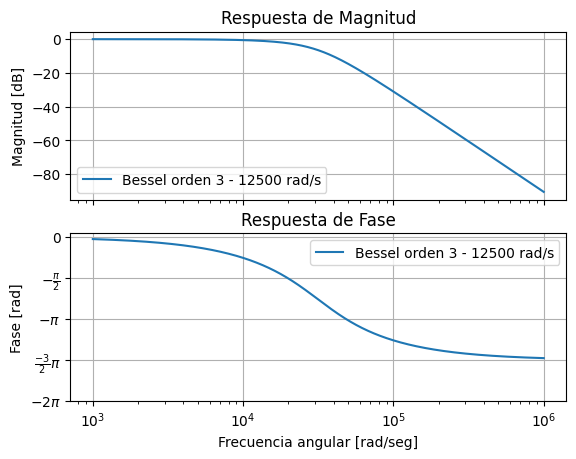

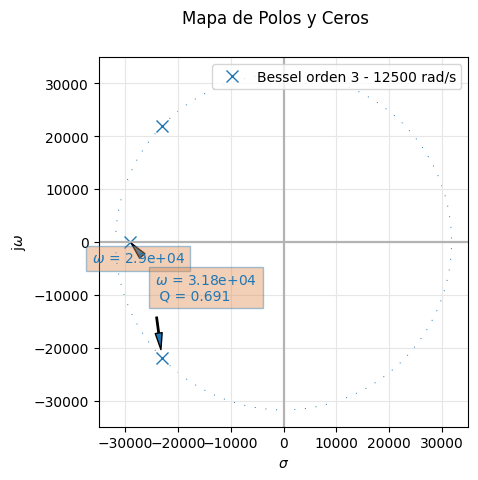

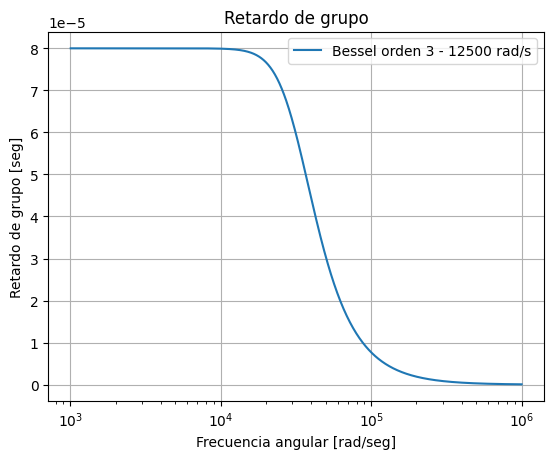

In [28]:
import sys
from pathlib import Path

pytc2_path = Path("../pytc2").resolve()
pytc2_parent = pytc2_path.parent
if str(pytc2_parent) not in sys.path:
    sys.path.insert(0, str(pytc2_parent))

import numpy as np
import matplotlib.pyplot as plt
import pytc2
import scipy.signal as sig

from pytc2.general import print_console_subtitle
from pytc2.sistemas_lineales import analyze_sys, pretty_print_SOS, tf2sos_analog

print(f"pytc2 version: {pytc2.__version__}")

nn = 3
omega_0 = 12500  # rad/s
omega_norm = "delay"

z, p, k = sig.besselap(nn, norm=omega_norm)
num_lp, den_lp = sig.zpk2tf(z, p, k)
num_lp, den_lp = sig.lp2lp(num_lp, den_lp, wo=omega_0)

sos_lp = tf2sos_analog(num_lp, den_lp)
tf_lp = sig.TransferFunction(num_lp, den_lp)

print_console_subtitle(f"Bessel pasabajo de orden {nn}")
pretty_print_SOS(sos_lp, mode="omegayq")
_, _, _, _ = analyze_sys(tf_lp, sys_name=f"Bessel orden {nn} - {omega_0:g} rad/s")

In [29]:
f_retardo = 3_000  # Hz
f_atenuacion = 2_000  # Hz
retardo_objetivo = 80e-6  # s
desvio_max = 5  # %
atenuacion_max = 1  # dB

w_retardo = 2 * np.pi * f_retardo
w_atenuacion = 2 * np.pi * f_atenuacion

_, h_atenuacion = sig.freqs(num_lp, den_lp, worN=[w_atenuacion])
atenuacion_2k = -20 * np.log10(abs(h_atenuacion[0]))

w = np.linspace(1, 40_000, 200_000)
_, h = sig.freqs(num_lp, den_lp, worN=w)
fase = np.unwrap(np.angle(h))
retardo_grupo = -np.gradient(fase, w)
retardo_continua = np.interp(0, w, retardo_grupo)
retardo_3k = np.interp(w_retardo, w, retardo_grupo)
desvio_3k = abs(retardo_3k - retardo_objetivo) / retardo_objetivo * 100

print_console_subtitle("Verificacion de especificaciones del grupo E")
print(f"Retardo en continua: {retardo_continua * 1e6:.3f} us")
print(f"Retardo @ 3 kHz: {retardo_3k * 1e6:.3f} us")
print(f"Desvio @ 3 kHz: {desvio_3k:.3f} % <= {desvio_max} % -> {desvio_3k <= desvio_max}")
print(f"Atenuacion @ 2 kHz: {atenuacion_2k:.3f} dB <= {atenuacion_max} dB -> {atenuacion_2k <= atenuacion_max}")



Verificacion de especificaciones del grupo E
--------------------------------------------

Retardo en continua: 80.000 us
Retardo @ 3 kHz: 77.458 us
Desvio @ 3 kHz: 3.177 % <= 5 % -> True
Atenuacion @ 2 kHz: 0.913 dB <= 1 dB -> True


### Respuesta en frecuencia y polos

La celda de Python anterior ejecuta `analyze_sys` sobre la transferencia Bessel ideal y genera la respuesta en frecuencia y el diagrama de polos y ceros.

En el diagrama de módulo se observa el comportamiento pasabajos del filtro. La ganancia es aproximadamente constante en la banda de paso y luego decrece de manera monótona al aumentar la frecuencia. La atenuación se verifica además numéricamente en $2\,\text{kHz}$ mediante el cálculo realizado en la celda siguiente.

La fase disminuye de forma continua con la frecuencia. Para un filtro Bessel-Thomson, esta variación es más suave que en otras aproximaciones pasabajos, lo que permite mantener un retardo de grupo aproximadamente constante en la banda de paso. En este caso, el retardo se evalúa en $3\,\text{kHz}$ y se compara su desvido con el objetivo de continua: $80\,\mu s$.

Los polos se encuentran en el semiplano izquierdo, por lo que el filtro ideal es estable. Al tratarse de un filtro Bessel de tercer orden, aparecen un polo real y un par complejo conjugado, correspondientes a la factorización en una sección RC de primer orden y una sección Sallen-Key de segundo orden desarrollada en el punto 1.

La diferencia respecto de un filtro pasabajos prototipo de igual orden está en el criterio de aproximación: Bessel-Thomson prioriza la linealidad de fase y la constancia del retardo de grupo, mientras que aproximaciones como Butterworth priorizan la planicidad del módulo y Chebyshev permiten mayor selectividad a costa de ondulaciones o peor comportamiento temporal.

Los gráficos que produce esta celda deben conservarse como salidas ejecutadas del notebook junto con los valores numéricos de retardo y atenuación.

<a id="p3"></a>

***

## 3. Implementación del filtro: Sallen-Key + RC

### 3.1 Topología utilizada

La implementación del filtro de tercer orden se realiza mediante la cascada de una sección Sallen-Key pasabajos de segundo orden y una sección RC pasabajos de primer orden.

<div align="center">
<img src="./img/resolucion_manuscrita_bessel_02.jpg" width="900" />
<img src="./img/resolucion_manuscrita_bessel_03.jpg" width="900" />
</div>

### 3.2 Transferencia de la sección Sallen-Key

Para la topología de la hoja manuscrita, con amplificador operacional en configuración seguidor, la transferencia de la sección Sallen-Key es (referencia: Tarea Semanal 4):

$$T_{SK}(s)=\frac{\dfrac{1}{R_1R_2C_1C_2}}{s^2+s\left(\dfrac{1}{R_1C_2}+\dfrac{1}{R_2C_2}\right)+\dfrac{1}{R_1R_2C_1C_2}}$$

Comparando con la forma canónica:

$$T_{SOS}(s)=\frac{\omega_0^2}{s^2+\dfrac{\omega_0}{Q}s+\omega_0^2}$$

se identifican:

$$\boxed{\omega_0^2=\frac{1}{R_1R_2C_1C_2}}$$

$$\boxed{\frac{\omega_0}{Q}=\frac{1}{R_1C_2}+\frac{1}{R_2C_2}}$$

Por lo tanto:

$$\boxed{\omega_0=\frac{1}{\sqrt{R_1R_2C_1C_2}}}$$

$$\boxed{Q=\frac{\sqrt{R_1R_2C_1C_2}}{C_1(R_1+R_2)}}$$

### 3.3 Transferencia de la sección RC

La sección de primer orden se implementa como un filtro RC independiente:

$$T_{RC}(s)=\frac{\dfrac{1}{R_3C_3}}{s+\dfrac{1}{R_3C_3}}$$

La transferencia total es:

$$T_3(s)=T_{SK}(s)\,T_{RC}(s)$$

### 3.4 Cálculo normalizado

Para la sección de segundo orden Bessel:

$$T_{SOS}(s)=\frac{6{,}461764}{s^2+3{,}6787s+6{,}461764}$$

Se toman resistencias normalizadas iguales:

$$R_1=R_2=1$$

Entonces, a partir del término independiente y del coeficiente de $s$:

$$\frac{1}{C_1C_2}=6{,}461764$$

$$\frac{1}{C_2}+\frac{1}{C_2}=\frac{2}{C_2}=3{,}6787$$

De donde:

$$\boxed{C_2=0{,}5436703183}$$

$$\boxed{C_1=\frac{1}{6{,}461764\,C_2}=0{,}2846513738}$$

Para el polo real de la sección RC:

$$T_{RC}(s)=\frac{2{,}3221}{s+2{,}3221}$$

con $R_3=1$:

$$\boxed{C_3=\frac{1}{2{,}3221}=0{,}4306446751}$$

### 3.5 Desnormalización y valores para el laboratorio

Se utiliza:

$$\Omega_\omega=12{,}5\,\text{krad/s}$$

$$R_1=R_2=R_3=10\,\text{k}\Omega$$

La transformación de los capacitores normalizados es:

$$C_{\mathrm{desnorm}}=\frac{C_{\mathrm{norm}}}{R\,\Omega_\omega}$$

Por lo tanto:

$$C_1=\frac{0{,}2846513738}{10\,\text{k}\Omega\cdot 12{,}5\,\text{krad/s}}=2{,}27721099\,\text{nF}$$

$$C_2=\frac{0{,}5436703183}{10\,\text{k}\Omega\cdot 12{,}5\,\text{krad/s}}=4{,}349362546\,\text{nF}$$

$$C_3=\frac{0{,}4306446751}{10\,\text{k}\Omega\cdot 12{,}5\,\text{krad/s}}=3{,}445157401\,\text{nF}$$

| Sección | Componente | Valor normalizado | Valor desnormalizado |
|:---|:---:|---:|---:|
| Sallen-Key | $R_1=R_2$ | $1$ | $10\,\text{k}\Omega$ |
| Sallen-Key | $C_1$ | $0{,}2846513738$ | $2{,}27721099\,\text{nF}$ |
| Sallen-Key | $C_2$ | $0{,}5436703183$ | $4{,}349362546\,\text{nF}$ |
| RC | $R_3$ | $1$ | $10\,\text{k}\Omega$ |
| RC | $C_3$ | $0{,}4306446751$ | $3{,}445157401\,\text{nF}$ |

Estos valores son los utilizados por las celdas de simulación y verificación del informe. La aproximación con valores comerciales y la verificación de las especificaciones se presentan en los puntos siguientes.

In [30]:
# Verificación de la implementación Sallen-Key + RC de referencia
R1 = R2 = R3 = 10_000  # Ohm
C1 = 2.27721099e-9  # F
C2 = 4.349362546e-9  # F
C3 = 3.445157401e-9  # F

omega_0_sk_cuad = 1 / (R1 * R2 * C1 * C2)
a1_sk = (R2 * C1 + R1 * C1) / (R1 * R2 * C1 * C2)
num_sk = np.array([omega_0_sk_cuad])
den_sk = np.array([1, a1_sk, omega_0_sk_cuad])

omega_0_rc = 1 / (R3 * C3)
num_rc = np.array([omega_0_rc])
den_rc = np.array([1, omega_0_rc])

num_impl = np.polymul(num_sk, num_rc)
den_impl = np.polymul(den_sk, den_rc)
num_impl = num_impl / den_impl[0]
den_impl = den_impl / den_impl[0]
tf_impl = sig.TransferFunction(num_impl, den_impl)

num_ideal = np.array(num_lp, dtype=float) / den_lp[0]
den_ideal = np.array(den_lp, dtype=float) / den_lp[0]

_, h_atenuacion_impl = sig.freqs(num_impl, den_impl, worN=[w_atenuacion])
atenuacion_2k_impl = -20 * np.log10(abs(h_atenuacion_impl[0]))
_, h_impl = sig.freqs(num_impl, den_impl, worN=w)
fase_impl = np.unwrap(np.angle(h_impl))
retardo_grupo_impl = -np.gradient(fase_impl, w)
retardo_3k_impl = np.interp(w_retardo, w, retardo_grupo_impl)
desvio_3k_impl = abs(retardo_3k_impl - retardo_objetivo) / retardo_objetivo * 100

# Para una cascada, el retardo en continua es la suma del retardo de cada etapa.
retardo_continua_impl = a1_sk / omega_0_sk_cuad + 1 / omega_0_rc

print_console_subtitle("Verificación Sallen-Key + RC de referencia")
print(f"Retardo en continua: {retardo_continua_impl * 1e6:.3f} us")
print(f"Retardo @ {f_retardo / 1000:.0f} kHz: {retardo_3k_impl * 1e6:.3f} us")
print(f"Desvío @ {f_retardo / 1000:.0f} kHz: {desvio_3k_impl:.3f} % <= {desvio_max} % -> {desvio_3k_impl <= desvio_max}")
print(f"Atenuación @ {f_atenuacion / 1000:.0f} kHz: {atenuacion_2k_impl:.3f} dB <= {atenuacion_max} dB -> {atenuacion_2k_impl <= atenuacion_max}")



Verificación Sallen-Key + RC de referencia
------------------------------------------

Retardo en continua: 79.996 us
Retardo @ 3 kHz: 77.448 us
Desvío @ 3 kHz: 3.190 % <= 5 % -> True
Atenuación @ 2 kHz: 0.913 dB <= 1 dB -> True


### Verificación numérica de la implementación de referencia

La celda anterior reconstruye la transferencia de la cascada Sallen-Key + RC a partir de los valores calculados y verifica el retardo y la atenuación del filtro. Esta verificación se realiza íntegramente en Python.

| Magnitud | Valor calculado | Requerimiento | Cumple |
|:---|---:|---:|:---|
| Retardo en continua | $79{,}996\,\mu s$ | $80\,\mu s$ | Sí (error mínimo) |
| Retardo a 3 kHz | $77{,}448\,\mu s$ | $80\,\mu s\pm5\,\%$ | Sí |
| Desvío del retardo a 3 kHz | $3{,}190\,\%$ | $\leq5\,\%$ | Sí |
| Atenuación a 2 kHz | $0{,}913\,\text{dB}$ | $\leq1\,\text{dB}$ | Sí |

#### Interpretación de la verificación

- **Retardo en continua:** es el retardo de grupo cuando la frecuencia tiende a cero ($f\to0$). Para la cascada Sallen-Key + RC se calcula sumando el retardo de ambas etapas. Se muestra como referencia del comportamiento de baja frecuencia; la especificación de diseño se verifica a 3 kHz.
- **Retardo a 3 kHz: 77,448 us:** es el retardo de grupo del filtro a la frecuencia especificada. El objetivo de diseño es $80\,\mu s$ con un error de no mas del 5% a 3kHz.
- **Desvío a 3 kHz: 3,190 %:** es la diferencia porcentual entre el retardo calculado y el objetivo de $80\,\mu s$. Como $3,190\,\%\leq5\,\%$, la condición de retardo se cumple.
- **Atenuación a 2 kHz: 0,913 dB:** indica cuánto se reduce la amplitud de la señal a 2 kHz. Como $0,913\,\text{dB}\leq1\,\text{dB}$, la condición de atenuación también se cumple.

La implementación cumple las especificaciones de retardo y atenuación del filtro Bessel de tercer orden.

<a id="p4"></a>

***

## 4. Valores comerciales y nueva simulacion

### Criterio de seleccion

Se compararan combinaciones de valores E24 y E96, manteniendo resistencias cercanas a 10 kOhm y verificando nuevamente los requisitos de retardo y atenuacion.

La celda siguiente realiza la busqueda de valores comerciales y calcula la respuesta de cada alternativa.

In [31]:
# Búsqueda y evaluación de valores comerciales
candidatos_comerciales = [
    {"nombre": "E24: R = 10 kOhm", "R1": 10_000, "R2": 10_000, "R3": 10_000, "C1": 2.2e-9, "C2": 4.3e-9, "C3": 3.6e-9},
    {"nombre": "E96: R = 10 kOhm", "R1": 10_000, "R2": 10_000, "R3": 10_000, "C1": 2.26e-9, "C2": 4.32e-9, "C3": 3.48e-9},
    {"nombre": "E24 capacitores + E96 resistores", "R1": 10_200, "R2": 10_200, "R3": 10_500, "C1": 2.2e-9, "C2": 4.3e-9, "C3": 3.3e-9},
    {"nombre": "E96 capacitores + E96 resistores", "R1": 10_500, "R2": 10_500, "R3": 9_530, "C1": 2.21e-9, "C2": 4.22e-9, "C3": 3.48e-9},
]

def transferencia_sallen_key_rc(R1, R2, R3, C1, C2, C3):
    omega_0_sk_cuad = 1 / (R1 * R2 * C1 * C2)
    a1_sk = (R2 * C1 + R1 * C1) / (R1 * R2 * C1 * C2)
    omega_0_rc = 1 / (R3 * C3)
    num = np.polymul([omega_0_sk_cuad], [omega_0_rc])
    den = np.polymul([1, a1_sk, omega_0_sk_cuad], [1, omega_0_rc])
    return num / den[0], den / den[0], np.sqrt(omega_0_sk_cuad), np.sqrt(omega_0_sk_cuad) / a1_sk, omega_0_rc

def evaluar_candidato(candidato):
    num, den, omega_0_sk, q_sk, omega_0_rc = transferencia_sallen_key_rc(
        candidato["R1"], candidato["R2"], candidato["R3"],
        candidato["C1"], candidato["C2"], candidato["C3"]
    )
    error_den = np.abs((den - den_ideal) / den_ideal) * 100
    error_num = abs((num[-1] - num_ideal[-1]) / num_ideal[-1]) * 100
    _, h_at = sig.freqs(num, den, worN=[w_atenuacion])
    atenuacion = -20 * np.log10(abs(h_at[0]))
    _, h_resp = sig.freqs(num, den, worN=w)
    fase_resp = np.unwrap(np.angle(h_resp))
    retardo_resp = -np.gradient(fase_resp, w)
    retardo = np.interp(w_retardo, w, retardo_resp)
    desvio = abs(retardo - retardo_objetivo) / retardo_objetivo * 100
    return {
        **candidato,
        "num": num,
        "den": den,
        "omega_0_sk": omega_0_sk,
        "q_sk": q_sk,
        "omega_0_rc": omega_0_rc,
        "error_den": error_den,
        "error_den_max": np.max(error_den),
        "error_num": error_num,
        "retardo": retardo,
        "desvio": desvio,
        "atenuacion": atenuacion,
        "cumple": desvio <= desvio_max and atenuacion <= atenuacion_max,
    }

def cap_serie(*capacitores):
    capacitores = np.array(capacitores, dtype=float)
    return 1 / np.sum(1 / capacitores)

def cap_paralelo(*capacitores):
    return np.sum(capacitores)

propuesta_simulada = {
    "nombre": "Propuesta simulada: R = 10 kOhm y capacitores combinados",
    "R1": 10_000,
    "R2": 10_000,
    "R3": 10_000,
    "C1": cap_serie(3.3e-9, 8.2e-9),
    "C2": cap_paralelo(2.2e-9, 2.2e-9),
    "C3": 3.3e-9,
}

resultados_comerciales = [evaluar_candidato(candidato) for candidato in candidatos_comerciales]
mejor_por_coeficientes = min(resultados_comerciales, key=lambda resultado: (resultado["error_den_max"], resultado["error_num"]))
resultado_propuesta = evaluar_candidato(propuesta_simulada)
tf_propuesta = sig.TransferFunction(resultado_propuesta["num"], resultado_propuesta["den"])

print_console_subtitle("Evaluación de valores comerciales")
for resultado in resultados_comerciales:
    print(resultado["nombre"])
    print(f"  Error máximo de coeficientes: {resultado['error_den_max']:.3f} %")
    print(f"  Retardo a 3 kHz: {resultado['retardo'] * 1e6:.3f} us; desvío: {resultado['desvio']:.3f} %")
    print(f"  Atenuación a 2 kHz: {resultado['atenuacion']:.3f} dB; cumple: {resultado['cumple']}")

print("\nMejor alternativa por error de coeficientes:")
print(mejor_por_coeficientes["nombre"])
print("\nPropuesta simulada con componentes combinados:")
print(f"  C1 = 3.3 nF en serie con 8.2 nF = {resultado_propuesta['C1'] / 1e-9:.6f} nF")
print(f"  C2 = 2.2 nF en paralelo con 2.2 nF = {resultado_propuesta['C2'] / 1e-9:.6f} nF")
print(f"  C3 = {resultado_propuesta['C3'] / 1e-9:.6f} nF")
print(f"  Retardo a 3 kHz: {resultado_propuesta['retardo'] * 1e6:.3f} us; desvío: {resultado_propuesta['desvio']:.3f} %")
print(f"  Atenuación a 2 kHz: {resultado_propuesta['atenuacion']:.3f} dB; cumple: {resultado_propuesta['cumple']}")



Evaluación de valores comerciales
---------------------------------

E24: R = 10 kOhm
  Error máximo de coeficientes: 0.947 %
  Retardo a 3 kHz: 76.739 us; desvío: 4.076 %
  Atenuación a 2 kHz: 0.934 dB; cumple: True
E96: R = 10 kOhm
  Error máximo de coeficientes: 0.463 %
  Retardo a 3 kHz: 77.157 us; desvío: 3.554 %
  Atenuación a 2 kHz: 0.922 dB; cumple: True
E24 capacitores + E96 resistores
  Error máximo de coeficientes: 0.720 %
  Retardo a 3 kHz: 77.492 us; desvío: 3.135 %
  Atenuación a 2 kHz: 0.888 dB; cumple: True
E96 capacitores + E96 resistores
  Error máximo de coeficientes: 0.435 %
  Retardo a 3 kHz: 78.092 us; desvío: 2.385 %
  Atenuación a 2 kHz: 0.873 dB; cumple: True

Mejor alternativa por error de coeficientes:
E96 capacitores + E96 resistores

Propuesta simulada con componentes combinados:
  C1 = 3.3 nF en serie con 8.2 nF = 2.353043 nF
  C2 = 2.2 nF en paralelo con 2.2 nF = 4.400000 nF
  C3 = 3.300000 nF
  Retardo a 3 kHz: 78.048 us; desvío: 2.440 %
  Atenuación a



Comparación ideal vs. propuesta simulada
----------------------------------------



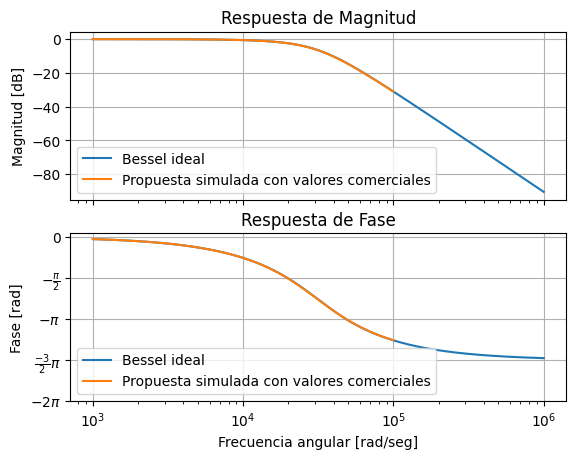

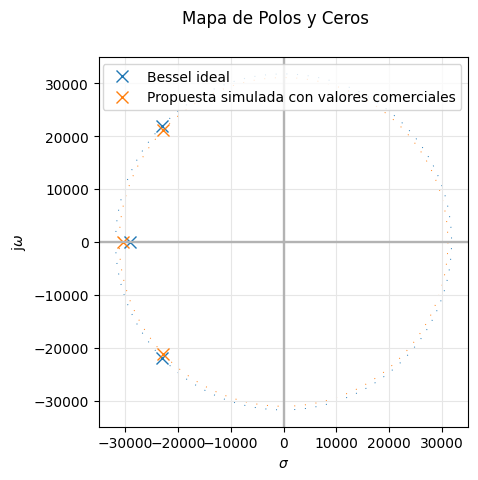

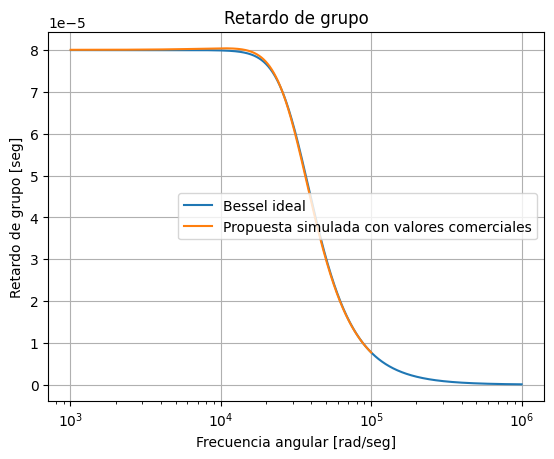

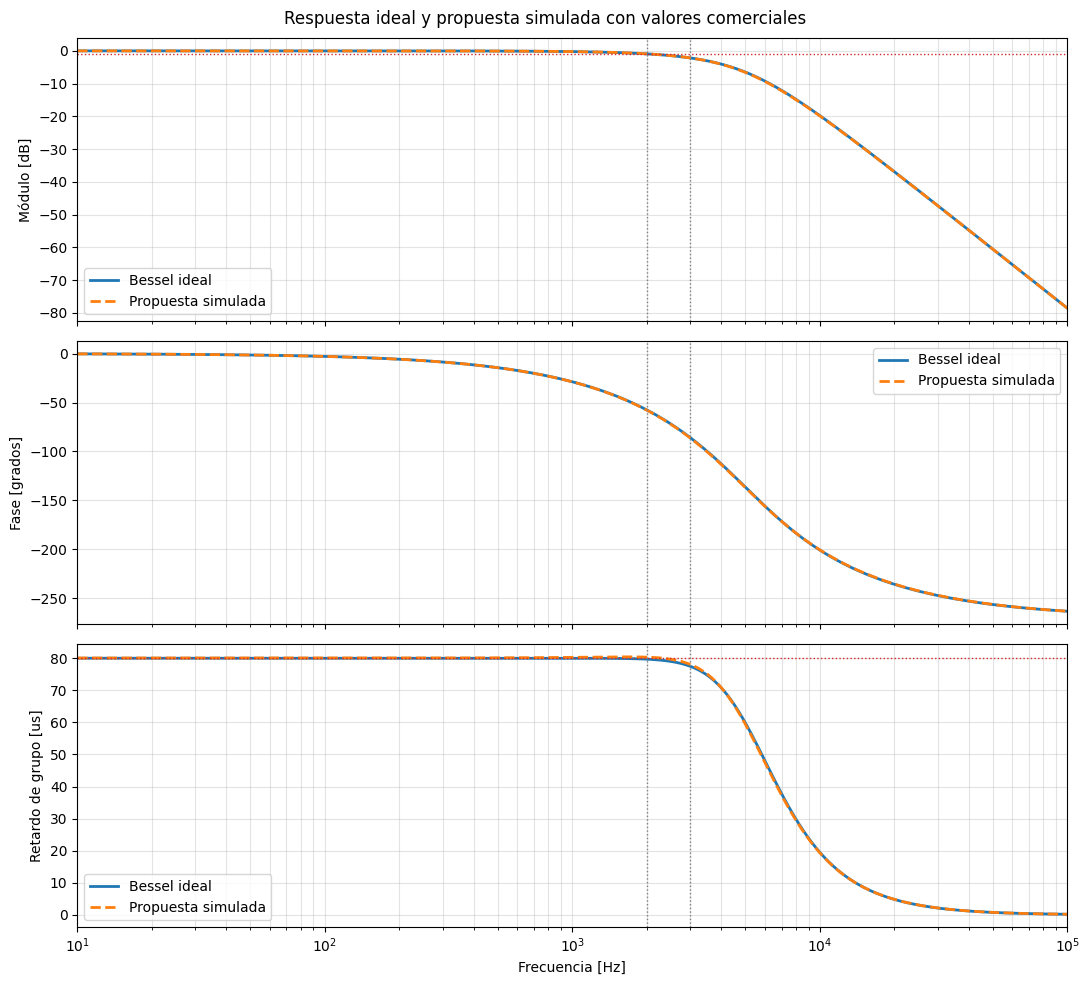

Ideal: A(2 kHz) = 0.913 dB, D(3 kHz) = 77.458 us
Propuesta: A(2 kHz) = 0.899 dB, D(3 kHz) = 78.048 us


In [32]:
# Comparación entre la transferencia ideal y la propuesta simulada con valores comerciales
print_console_subtitle("Comparación ideal vs. propuesta simulada")
analyze_sys(
    [tf_lp, tf_propuesta],
    sys_name=["Bessel ideal", "Propuesta simulada con valores comerciales"],
    annotations=False,
    same_figs=False,
)
plt.show()

f_comparacion = np.logspace(1, 5, 20_000)
w_comparacion = 2 * np.pi * f_comparacion
_, h_ideal = sig.freqs(num_lp, den_lp, worN=w_comparacion)
_, h_propuesta = sig.freqs(resultado_propuesta["num"], resultado_propuesta["den"], worN=w_comparacion)

modulo_ideal = 20 * np.log10(np.abs(h_ideal))
modulo_propuesta = 20 * np.log10(np.abs(h_propuesta))
fase_ideal = np.unwrap(np.angle(h_ideal)) * 180 / np.pi
fase_propuesta = np.unwrap(np.angle(h_propuesta)) * 180 / np.pi
retardo_ideal = -np.gradient(np.unwrap(np.angle(h_ideal)), w_comparacion) * 1e6
retardo_propuesta = -np.gradient(np.unwrap(np.angle(h_propuesta)), w_comparacion) * 1e6

fig, ejes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
curvas = [
    (modulo_ideal, modulo_propuesta, "Módulo [dB]"),
    (fase_ideal, fase_propuesta, "Fase [grados]"),
    (retardo_ideal, retardo_propuesta, "Retardo de grupo [us]"),
]

for eje, (ideal, propuesta, etiqueta) in zip(ejes, curvas):
    eje.semilogx(f_comparacion, ideal, lw=2, label="Bessel ideal")
    eje.semilogx(f_comparacion, propuesta, lw=2, ls="--", label="Propuesta simulada")
    eje.axvline(f_atenuacion, color="gray", ls=":", lw=1)
    eje.axvline(f_retardo, color="gray", ls=":", lw=1)
    eje.set_ylabel(etiqueta)
    eje.grid(True, which="both", alpha=0.35)
    eje.legend(loc="best")

ejes[0].axhline(-atenuacion_max, color="C3", ls=":", lw=1, label="Límite de atenuación")
ejes[2].axhline(retardo_objetivo * 1e6, color="C3", ls=":", lw=1, label="Retardo objetivo")
ejes[2].set_xlabel("Frecuencia [Hz]")
ejes[2].set_xlim(f_comparacion[0], f_comparacion[-1])
fig.suptitle("Respuesta ideal y propuesta simulada con valores comerciales")
fig.tight_layout()
plt.show()

print(f"Ideal: A(2 kHz) = {atenuacion_2k:.3f} dB, D(3 kHz) = {retardo_3k * 1e6:.3f} us")
print(f"Propuesta: A(2 kHz) = {resultado_propuesta['atenuacion']:.3f} dB, D(3 kHz) = {resultado_propuesta['retardo'] * 1e6:.3f} us")

### Selección de valores comerciales

Las alternativas se evaluaron con la misma transferencia Sallen-Key + RC, comparando el desvío de retardo, la atenuación en banda de paso y la disponibilidad de componentes. Esta evaluación corresponde a alternativas técnicas de simulación y se conserva para contrastarla con el circuito que se utilizó en el armado previo.

| Alternativa | $R_1=R_2=R_3$ | $C_1$ [nF] | $C_2$ [nF] | $C_3$ [nF] | Desvío a 3 kHz | Atenuación a 2 kHz | Cumple |
|:---|---:|---:|---:|---:|---:|---:|:---:|
| E24 | $10\,\text{k}\Omega$ | $2{,}20$ | $4{,}30$ | $3{,}60$ | $4{,}076\,\%$ | $0{,}934\,\text{dB}$ | Sí |
| E96 | $10\,\text{k}\Omega$ | $2{,}26$ | $4{,}32$ | $3{,}48$ | $3{,}554\,\%$ | $0{,}922\,\text{dB}$ | Sí |
| E24 + resistores E96 | $10{,}2/10{,}2/10{,}5\,\text{k}\Omega$ | $2{,}20$ | $4{,}30$ | $3{,}30$ | $3{,}135\,\%$ | $0{,}888\,\text{dB}$ | Sí |
| E96 + resistores E96 | $10{,}5/10{,}5/9{,}53\,\text{k}\Omega$ | $2{,}21$ | $4{,}22$ | $3{,}48$ | $2{,}385\,\%$ | $0{,}873\,\text{dB}$ | Sí |
| Diseño propio con valores comerciales | $10\,\text{k}\Omega$ | $2{,}353043$ | $4{,}40$ | $3{,}30$ | $2{,}440\,\%$ | $0{,}899\,\text{dB}$ | Sí |

La alternativa E96 con resistores E96 minimiza el error de coeficientes. El diseño propio con capacitores combinados es la selección documentada por las capturas LTspice incluidas al final de este punto. El circuito que se utilizó en el armado previo, elaborado por un compañero, se identifica en los puntos 5 a 7.

### Comparación numérica del diseño propio

La celda de comparación anterior genera las respuestas de módulo, fase y retardo de grupo para la transferencia ideal y para el diseño propio con valores comerciales. `analyze_sys` muestra además el Bode y el mapa de polos y ceros; Matplotlib presenta ambas respuestas superpuestas en función de la frecuencia.

| Diseño | Atenuación a 2 kHz | Retardo a 3 kHz |
|:---|---:|---:|
| Bessel ideal | $0{,}913\,\text{dB}$ | $77{,}458\,\mu s$ |
| Diseño propio con valores comerciales | $0{,}899\,\text{dB}$ | $78{,}048\,\mu s$ |

Las curvas prácticamente se superponen en la banda de paso. La diferencia de los componentes comerciales introduce una variación pequeña en módulo, fase y retardo, sin modificar la estabilidad ni el comportamiento Bessel esperado.

### Realización de $C_1$ con componentes disponibles

El valor $C_1=2{,}35304\,\text{nF}$ no corresponde a un capacitor individual. Según la lista de materiales [componentes_circuito_principal.csv](componentes_circuito_principal.csv), se implementa con $C_{1a}=3{,}3\,\text{nF}$ y $C_{1b}=8{,}2\,\text{nF}$ conectados en serie:

$$C_1=C_{1a}\parallel_s C_{1b}=\frac{C_{1a}C_{1b}}{C_{1a}+C_{1b}}=\frac{(3{,}3)(8{,}2)}{3{,}3+8{,}2}\,\text{nF}=2{,}35304\,\text{nF}$$

La misma lista identifica los componentes como `C1a` y `C1b`, ambos de película o cerámicos C0G/NP0. Por lo tanto, en el esquema y las simulaciones, el rótulo $C_1$ representa la capacitancia equivalente de esa serie.

### Recomendaciones de montaje y ajuste del diseño propio

Las siguientes indicaciones corresponden al diseño propio de resistencias nominales de $10\,\text{k}\Omega$; son recomendaciones de montaje y no reemplazan los valores medidos del armado previo documentado en el punto 6.

- Para cada resistencia crítica puede emplearse una resistencia fija de $9{,}1\,\text{k}\Omega$ en serie con un preset multiturno de $2\,\text{k}\Omega$: $R=9{,}1\,\text{k}\Omega+P_{2\,\text{k}\Omega}$. Esto permite un rango de ajuste aproximado entre $9{,}1\,\text{k}\Omega$ y $11{,}1\,\text{k}\Omega$.
- El ajuste inicial debe llevar $R_1$, $R_2$ y $R_3$ a $10\,\text{k}\Omega$. Conviene ajustar primero $R_1$ y $R_2$ lo más iguales posible, porque determinan la sección Sallen-Key; luego se ajusta $R_3$, que modifica principalmente el polo de la etapa RC.
- Se recomienda colocar un capacitor de desacople de $100\,\text{nF}$ junto a cada riel de alimentación del amplificador operacional. Como desacople adicional de baja frecuencia, pueden añadirse capacitores de $10\,\mu\text{F}$ en los rieles de alimentación, próximos al circuito.

### Evidencia LTspice del diseño propio

Las siguientes capturas corresponden al diseño propio con $R_1=R_2=R_3=10\,\text{k}\Omega$, $C_1=2{,}35304\,\text{nF}$ (equivalente de $3{,}3\,\text{nF}$ en serie con $8{,}2\,\text{nF}$), $C_2=4{,}4\,\text{nF}$ y $C_3=3{,}3\,\text{nF}$. Documentan su simulación con valores comerciales; no son mediciones del montaje físico.

<div align="center"><img src="./img/esquema_diseno_propio_valores_comerciales.jpeg" width="950" /></div>

<div align="center"><img src="./img/simulacion_ltspice_diseno_propio_2khz.jpeg" width="950" /></div>

> **Cursor a 2 kHz:** $f=2{,}0003224\,\text{kHz}$, $|V_o/V_i|=-0{,}898628\,\text{dB}$, fase $=-57{,}818488°$ y retardo de grupo $=80{,}377312\,\mu s$.

<div align="center"><img src="./img/simulacion_ltspice_diseno_propio_3khz.jpeg" width="950" /></div>

> **Cursor a 3 kHz:** $f=3{,}000544\,\text{kHz}$, $|V_o/V_i|=-2{,}163166\,\text{dB}$, fase $=-86{,}46961°$ y retardo de grupo $=78{,}101231\,\mu s$.

<div align="center"><img src="./img/simulacion_ltspice_diseno_propio_retardo_3khz.jpeg" width="950" /></div>

> **Retardo de grupo a 3 kHz:** $78{,}101231\,\mu s$, con un desvío de $2{,}37\,\%$ respecto de $80\,\mu s$; cumple el máximo de $5\,\%$.

<a id="p5"></a>

***

## 5. Diseño utilizado en el armado previo

> **Fuente y alcance:** los valores y la topología de esta sección se transcriben del documento de diseño elaborado por un compañero del grupo (Juan Manuel Contreras) ya que se decidio usar su diseño, mas alla de haber hecho un diseño propio previamente. Se incluyen únicamente los datos necesarios para identificar y verificar el circuito empleado; el desarrollo completo se referencia en dicho documento, de autoría de su autor y esta en el PDF TPLab_260612_140942.pdf.

El circuito utilizado es un filtro pasabajos Bessel de tercer orden compuesto por una etapa RC de primer orden y una etapa Sallen-Key de segundo orden, ambas aisladas mediante seguidores de tensión. En el esquema, la señal atraviesa primero la etapa RC y luego la Sallen-Key; por estar desacopladas, las transferencias de ambas etapas se multiplican.

| Etapa | Elemento | Valor utilizado | Función |
|:---|:---|---:|:---|
| RC | $R_{RC}$ | $33\,\text{k}\Omega$ | Resistencia serie de la etapa de primer orden |
| RC | $C_{RC}$ | $1\,\text{nF}$ | Capacitor a masa de la etapa de primer orden |
| Sallen-Key | $R_{SK1}$ | $33\,\text{k}\Omega$ | Resistencia desde el primer seguidor al nodo intermedio |
| Sallen-Key | $R_{SK2}$ | $15\,\text{k}\Omega$ | Resistencia desde el nodo intermedio a la entrada no inversora |
| Sallen-Key | $C_f$ | $2{,}2\,\text{nF}$ | Capacitor de realimentación entre salida y nodo intermedio |
| Sallen-Key | $C_g$ | $1\,\text{nF}$ | Capacitor desde la entrada no inversora a masa |

Con estos valores, ambas secciones quedan próximas a la misma pulsación característica: $\omega_{0,SK}\approx\omega_{0,RC}\approx30{,}303\,\text{rad/s}$. La sección Sallen-Key tiene $Q\approx0{,}688$, coherente con el factor de segundo orden de la aproximación Bessel de orden 3.

La siguiente celda verifica numéricamente este diseño a partir de la transferencia consignada en el documento fuente. Esta verificación es parte de este informe y no reproduce su desarrollo analítico.

In [33]:
# Verificación numérica del diseño utilizado en el armado previo
# C_f es el capacitor de realimentación y C_g el capacitor a masa de la sección Sallen-Key.
diseno_utilizado = {
    "R_SK1": 33e3,
    "R_SK2": 15e3,
    "C_f": 2.2e-9,
    "C_g": 1e-9,
    "R_RC": 33e3,
    "C_RC": 1e-9,
}

omega_0_sk_utilizado_cuad = 1 / (
    diseno_utilizado["R_SK1"] * diseno_utilizado["R_SK2"]
    * diseno_utilizado["C_f"] * diseno_utilizado["C_g"]
)
a1_sk_utilizado = (1 / diseno_utilizado["C_f"]) * (
    1 / diseno_utilizado["R_SK1"] + 1 / diseno_utilizado["R_SK2"]
)
omega_0_rc_utilizado = 1 / (diseno_utilizado["R_RC"] * diseno_utilizado["C_RC"])

num_utilizado = np.polymul([omega_0_sk_utilizado_cuad], [omega_0_rc_utilizado])
den_utilizado = np.polymul(
    [1, a1_sk_utilizado, omega_0_sk_utilizado_cuad],
    [1, omega_0_rc_utilizado],
)
tf_utilizado = sig.TransferFunction(num_utilizado, den_utilizado)
q_sk_utilizado = np.sqrt(omega_0_sk_utilizado_cuad) / a1_sk_utilizado

f_utilizado = np.logspace(1, 5, 200_000)
w_utilizado = 2 * np.pi * f_utilizado
_, h_utilizado = sig.freqs(num_utilizado, den_utilizado, worN=w_utilizado)
retardo_utilizado = -np.gradient(np.unwrap(np.angle(h_utilizado)), w_utilizado)

def metricas_utilizado(frecuencia_hz):
    _, respuesta = sig.freqs(num_utilizado, den_utilizado, worN=[2 * np.pi * frecuencia_hz])
    atenuacion_db = -20 * np.log10(abs(respuesta[0]))
    retardo_us = np.interp(frecuencia_hz, f_utilizado, retardo_utilizado) * 1e6
    return atenuacion_db, retardo_us

atenuacion_utilizado_2k, retardo_utilizado_2k = metricas_utilizado(2e3)
atenuacion_utilizado_3k, retardo_utilizado_3k = metricas_utilizado(3e3)
desvio_utilizado_3k = abs(retardo_utilizado_3k - 80) / 80 * 100

print_console_subtitle("Verificación del diseño utilizado")
print(f"Q de Sallen-Key: {q_sk_utilizado:.4f}")
print(f"A(2 kHz): {atenuacion_utilizado_2k:.3f} dB; D(2 kHz): {retardo_utilizado_2k:.3f} us")
print(f"A(3 kHz): {atenuacion_utilizado_3k:.3f} dB; D(3 kHz): {retardo_utilizado_3k:.3f} us")
print(f"Desvío de retardo a 3 kHz: {desvio_utilizado_3k:.3f} %")
print(f"Cumplimiento: atenuación <= 1 dB: {atenuacion_utilizado_2k <= 1}; desvío <= 5 %: {desvio_utilizado_3k <= 5}")



Verificación del diseño utilizado
---------------------------------

Q de Sallen-Key: 0.6875
A(2 kHz): 0.899 dB; D(2 kHz): 81.760 us
A(3 kHz): 2.192 dB; D(3 kHz): 79.527 us
Desvío de retardo a 3 kHz: 0.591 %
Cumplimiento: atenuación <= 1 dB: True; desvío <= 5 %: True


<a id="p6"></a>

***

## 6. Componentes del diseño utilizado

Durante el armado previo se ajustaron las resistencias y se relevaron los valores efectivos que se indican a continuación; estos son los valores a utilizar al comparar la respuesta del circuito físico con la simulación.

### Valores medidos en el circuito armado

| Componente | Valor medido | Método de medición | Observación |
|:---|---:|:---|:---|
| $R_1$ | $32{,}86\,\text{k}\Omega$ | Multímetro, aislada del circuito mediante jumpers | Resistencia fija más elemento de ajuste |
| $R_2$ | $26{,}63\,\text{k}\Omega$ | Multímetro, aislada del circuito mediante jumpers | Resistencia fija más elemento de ajuste |
| $R_3$ | $11{,}91\,\text{k}\Omega$ | Multímetro, aislada del circuito mediante jumpers | Resistencia fija más elemento de ajuste |
| $C_1$ | $1{,}07\,\text{nF}$ | Multímetro antes de soldar | Capacitor seleccionado para el armado |
| $C_2$ | $2{,}14\,\text{nF}$ | Multímetro antes de soldar | Capacitor seleccionado para el armado |
| $C_3$ | $1{,}01\,\text{nF}$ | Multímetro antes de soldar | Capacitor seleccionado para el armado |

<div align="center"><img src="./img/valores_medidos_componentes.jpeg" width="600" /></div>

> **Registro de laboratorio:** valores medidos antes de la prueba final. Las resistencias se midieron con los jumpers de aislamiento desconectados, evitando que otros caminos del circuito alteraran la lectura. Cada resistencia efectiva resulta de una resistencia fija en serie con un potenciómetro o preset de ajuste. Los capacitores se midieron antes de soldarlos a la placa experimental.

### Lista de materiales

| Material | Cantidad | Uso |
|:---|:---:|:---|
| Resistencias fijas y capacitores | Según los valores anteriores | Implementación de las secciones RC y Sallen-Key |
| TL082 | 1, se usa un OPAMP para el SK y el otro como separador de las etapas | Amplificadores operacionales para las etapas activas y separador de etapas |
| Placa perforada experimental | 1 | Montaje del circuito |
| Potenciómetros y presets multivueltas | Según cada ajuste | Calibración de los valores resistivos |
| Terminales, jumpers y cables | Según necesidad | Conexionado, alimentación, medición y aislamiento de resistencias |


<a id="p7"></a>

***

## 7. Simulación LTspice y armado del diseño utilizado

Esta sección presenta el esquema y la evidencia de simulación recibidos junto con el documento de diseño. Corresponden al circuito utilizado en el armado previo, elaborado por un compañero del grupo. Las simulaciones del diseño propio con valores comerciales se documentan en el punto 4.

### Esquema del circuito utilizado

<div align="center"><img src="./img/esquema_diseno_utilizado.png" width="950" /></div>

> **Figura:** circuito empleado: etapa RC de $33\,\text{k}\Omega$ y $1\,\text{nF}$, seguida por un Sallen-Key con $R_{SK1}=33\,\text{k}\Omega$, $R_{SK2}=15\,\text{k}\Omega$, $C_f=2{,}2\,\text{nF}$ y $C_g=1\,\text{nF}$. La topología y la imagen pertenecen al documento de diseño de su autor.

### Verificación LTspice a 2 kHz

<div align="center"><img src="./img/simulacion_ltspice_diseno_utilizado_2khz.png" width="950" /></div>

El cursor de LTspice se ubicó en $f=2{,}0030488\,\text{kHz}$ y muestra:

| Magnitud | Resultado LTspice | Requisito | Cumple |
|:---|---:|---:|:---:|
| Módulo $\lvert V_o/V_i\rvert$ | $-0{,}900933\,\text{dB}$ | Atenuación $\leq1\,\text{dB}$ a 2 kHz | Sí |
| Fase | $-58{,}716372°$ | - | - |
| Retardo de grupo | $81{,}814632\,\mu s$ | Referencia: $80\,\mu s$ | - |

La atenuación de la captura concuerda con la verificación numérica incluida en el punto anterior: $0{,}899\,\text{dB}$ a 2 kHz. La diferencia se debe a la frecuencia exacta del cursor y al modelo de simulación.

### Verificación del requisito de retardo

La captura proporcionada documenta el cursor a 2 kHz. Para 3 kHz, la celda de verificación del punto 5, evaluada a partir de los valores finales, obtiene $D(3\,\text{kHz})=79{,}527\,\mu s$, equivalente a un desvío de $0{,}591\,\%$ respecto de $80\,\mu s$; por lo tanto satisface el límite de $5\,\%$ del modelo nominal.

### Armado en placa perforada experimental

<div align="center"><img src="./img/foto_armado_placa_experimental.jpeg" width="760" /></div>

> **Figura:** montaje previo a la prueba final sobre placa perforada experimental. Se observan los circuitos integrados, los presets multivueltas, terminales de conexión, jumpers y cables utilizados para el ajuste y la verificación del circuito.

### Observación de entrada y salida en osciloscopio

<div align="center"><img src="./img/captura_osciloscopio_entrada_salida.jpeg" width="760" /></div>

> **Registro preliminar:** se observan dos señales correspondientes a entrada y salida. La captura no contiene una frecuencia de ensayo ni acotaciones definitivas de canal, amplitud, fase y retardo; por ese motivo se conserva como evidencia cualitativa y no se extraen métricas numéricas de ella.

> Los resultados LTspice y esta observación de banco no reemplazan las mediciones finales del montaje real, que se registran mediante el barrido instrumental presentado en el punto 8.


<a id="p8"></a>

***

## 8. Práctica de laboratorio y observaciones

Esta sección documenta el banco de medición, los instrumentos utilizados, el procedimiento seguido y la evidencia fotográfica del armado previo a la prueba final.

### 8.1 Conexión del banco de medición

<div align="center"><img src="./img/diagrama_conexion_laboratorio.svg" width="900" /></div>

La salida del generador de señales se conectó a la entrada $V_i$ del filtro. El canal 1 del osciloscopio se conectó sobre $V_i$ y el canal 2 sobre $V_o$, ambos con referencia común. Las fuentes regulables se conectaron a los rieles de alimentación del circuito activo.

### 8.2 Instrumental utilizado

| Instrumento | Modelo | Identificador visible | Uso durante la práctica |
|:---|:---|:---|:---|
| Multímetro | UNI-T UT60A | `NG1821` | Verificación de cortocircuitos, ajuste de fuentes y medición de componentes |
| Fuentes regulables | V&A HY3005D | `NG1357` y `NG1354` | Alimentación regulada; configuración en modo de tensión o de corriente |
| Generador de señales arbitrarias | Twintex TFG-3205E, 5 MHz | `NG1903` | Excitación senoidal del filtro |
| Osciloscopio digital | GW Instek GDS-1072A-U, 70 MHz, 1 GSa/s | `NG1396` | Observación simultánea de $V_i$ y $V_o$, fase y retardo |

Los identificadores `NG` son los rótulos visibles en el instrumental del laboratorio. También se fotografió un analizador de audio Agilent U8903A (`NG1652`).

### 8.3 Procedimiento seguido

1. Se inspeccionó visualmente el circuito y se verificó con el multímetro la ausencia de cortocircuitos y la correcta soldadura de los componentes.
2. Se configuró la limitación de corriente de cada fuente en algunas decenas de mA: con los bornes en corto y una tensión baja, aproximadamente $1\,\text{V}$, se ajustó el nivel de corriente en modo CC.
3. Se calibró la tensión de alimentación con el multímetro antes de energizar el circuito. La tensión se ajustó con el circuito desconectado y luego se aplicó al montaje.
4. Se verificaron las puntas del osciloscopio con la señal de prueba en los canales 1 y 2, ajustando la visualización temporal y comprobando amplitud AC y período.
5. Se calibró una señal senoidal de valor medio nulo en el generador, con amplitud adecuada para medir en banda de paso. Se consideró la posibilidad de sobretensión a la salida del filtro.
6. Se eligió una frecuencia en la región media de la banda de paso, con impedancia de carga del generador de al menos $1\,\text{k}\Omega$ cuando fue posible.
7. Con el circuito desenergizado se conectó el integrado TL082; luego se restablecieron la alimentación y la señal de entrada.
8. Se comprobó con el osciloscopio la presencia de señal de salida, de forma semejante a la entrada y con las diferencias esperables de fase y amplitud.
9. Se realizó un barrido rápido y cualitativo de frecuencia para verificar la atenuación de la salida al aumentar la frecuencia.

### 8.4 Registro del montaje y configuraciones preliminares

<div style="display:grid; grid-template-columns:repeat(2, minmax(0, 1fr)); gap:12px; align-items:start;">
  <figure style="margin:0;"><img src="./img/laboratorio_placa_aislada.jpeg" style="width:100%; height:auto;" /><figcaption>Placa perforada durante la verificación inicial.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_placa_conectada.jpeg" style="width:100%; height:auto;" /><figcaption>Montaje conectado a alimentación, puntas y terminales de prueba.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_placa_detalle.jpeg" style="width:100%; height:auto;" /><figcaption>Detalle del circuito con presets, jumpers y puntos de conexión.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_osciloscopio_cursores_100khz.jpeg" style="width:100%; height:auto;" /><figcaption>Captura preliminar con cursores a aproximadamente $100\,\text{kHz}$.</figcaption></figure>
</div>

La captura del osciloscopio muestra una frecuencia indicada de aproximadamente $99{,}994\,\text{kHz}$ y un intervalo entre cursores de $7{,}500\,\mu s$. Es una comprobación funcional preliminar del banco; no se emplea para verificar los requisitos de atenuación a 2 kHz ni de retardo a 3 kHz.

### 8.5 Registro fotográfico del instrumental

Las figuras se presentan en grillas de dos columnas para conservar la trazabilidad visual del banco sin ocupar una página por fotografía.

#### Multímetro y osciloscopio

<div style="display:grid; grid-template-columns:repeat(2, minmax(0, 1fr)); gap:12px; align-items:start;">
  <figure style="margin:0;"><img src="./img/laboratorio_multimetro_uni_t_ut60a.jpeg" style="width:100%; height:auto;" /><figcaption>Multímetro UNI-T UT60A.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_identificacion_multimetro_ng1821.jpeg" style="width:100%; height:auto;" /><figcaption>Identificador visible del multímetro: `NG1821`.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_osciloscopio_gw_instek_gds1072au.jpeg" style="width:100%; height:auto;" /><figcaption>Osciloscopio GW Instek GDS-1072A-U.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_identificacion_osciloscopio_ng1396.jpeg" style="width:100%; height:auto;" /><figcaption>Identificador visible del osciloscopio: `NG1396`.</figcaption></figure>
</div>

#### Fuentes regulables

<div style="display:grid; grid-template-columns:repeat(2, minmax(0, 1fr)); gap:12px; align-items:start;">
  <figure style="margin:0;"><img src="./img/laboratorio_fuentes_hy3005d_frontal.jpeg" style="width:100%; height:auto;" /><figcaption>Dos fuentes regulables V&A HY3005D, con controles independientes de corriente y tensión.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_identificacion_fuentes_ng1357_ng1354.jpeg" style="width:100%; height:auto;" /><figcaption>Identificadores visibles: `NG1357` y `NG1354`.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_fuentes_conexion.jpeg" style="width:100%; height:auto;" /><figcaption>Fuentes conectadas para la alimentación del banco.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_fuentes_ajuste_14v8.jpeg" style="width:100%; height:auto;" /><figcaption>Registro visual de un ajuste preliminar de tensión cercano a $14{,}7$-$14{,}8\,\text{V}$.</figcaption></figure>
</div>

#### Generador de señales y equipos auxiliares

<div style="display:grid; grid-template-columns:repeat(2, minmax(0, 1fr)); gap:12px; align-items:start;">
  <figure style="margin:0;"><img src="./img/laboratorio_generador_twintex_tfg3205e.jpeg" style="width:100%; height:auto;" /><figcaption>Generador Twintex TFG-3205E de 5 MHz.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_identificacion_generador_ng1903.jpeg" style="width:100%; height:auto;" /><figcaption>Identificador visible del generador: `NG1903`.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_generador_senoidal_100khz.jpeg" style="width:100%; height:auto;" /><figcaption>Configuración senoidal de referencia a $100\,\text{kHz}$.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_generador_amplitud_20vpp.jpeg" style="width:100%; height:auto;" /><figcaption>Registro de amplitud configurada de $20\,\text{Vpp}$.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_generador_salida_desactivada.jpeg" style="width:100%; height:auto;" /><figcaption>Estado de salida desactivada durante el conexionado.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_fuentes_y_generador.jpeg" style="width:100%; height:auto;" /><figcaption>Vista conjunta de las fuentes regulables y del generador.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_analizador_audio_agilent_u8903a.jpeg" style="width:100%; height:auto;" /><figcaption>Analizador de audio Agilent U8903A, identificador `NG1652`, registrado durante la sesión.</figcaption></figure>
  <figure style="margin:0;"><img src="./img/laboratorio_identificacion_fuentes_hy3005d.jpeg" style="width:100%; height:auto;" /><figcaption>Vista adicional de identificación de las fuentes V&A HY3005D.</figcaption></figure>
</div>

### Valores finales de la prueba de laboratorio

Luego de una primera comparación con la simulación, se realizó una iteración en LTspice durante la práctica para ajustar el circuito a los valores observados en el laboratorio. La configuración final quedó representada por los siguientes valores medidos:

| Componente | Valor final medido | Función en el circuito |
|:---|:---:|:---|
| $R_2$ | $33{,}771\,\Omega$ | Resistencia de la etapa RC de entrada |
| $R_3$ | $2{,}630\,\Omega$ | Resistencia serie inicial de la sección Sallen-Key |
| $R_4$ | $17{,}170\,\Omega$ | Resistencia restante de la sección Sallen-Key |
| $C_2$ | $1{,}01\,\text{nF}$ | Capacitor de la etapa RC de entrada |
| $C_3$ | $2{,}14\,\text{nF}$ | Capacitor de realimentación de Sallen-Key |
| $C_4$ | $1{,}07\,\text{nF}$ | Capacitor conectado a masa en Sallen-Key |

<div style="height:24px;"></div>

<div align="center"><img src="./img/esquema_final_ajustado_ltspice.jpg" width="850" /></div>

<div style="height:16px;"></div>

> **Figura:** configuración final del circuito en LTspice, con los valores resistivos ajustados durante la práctica y los valores capacitivos medidos previamente.

La iteración en LTspice se utilizó para determinar qué valores resistivos convenía modificar antes de realizar la medición final. Durante el ajuste físico, las resistencias fueron los únicos componentes modificados: se podían aislar mediante los jumpers de la placa y medir individualmente con el multímetro, mientras que su valor se regulaba mediante el potenciómetro o preset asociado.

Los capacitores no se modificaron durante esta etapa. Se conservaron los valores medidos previamente y se utilizaron como parte fija del circuito: $C_2=1{,}01\,\text{nF}$, $C_3=2{,}14\,\text{nF}$ y $C_4=1{,}07\,\text{nF}$. Por lo tanto, la iteración consistió en ajustar únicamente $R_2$, $R_3$ y $R_4$ hasta obtener la respuesta buscada.

Estos valores corresponden a la configuración final efectivamente medida en el laboratorio y deben distinguirse de los valores nominales o de las alternativas simuladas presentadas en las secciones anteriores. La medición con jumpers desconectados permitió evitar caminos paralelos del circuito y obtener el valor real de cada resistencia ajustable.

### 8.6 Primera aproximación: mediciones con osciloscopio

El archivo `datos/mediciones_osciloscopio_inicial.csv` conserva el primer barrido realizado manualmente con el osciloscopio. Contiene $21$ mediciones válidas entre $200\,\text{Hz}$ y $100\,\text{kHz}$; las filas finales con `#DIV/0!` se omiten durante la carga.

El retardo de grupo se calculó en la hoja de mediciones mediante diferencia finita de la fase. La fórmula utilizada en la celda de retardo de grupo fue:

```text
=IF(OR(G2="";G3="";A2="";A3="");"";-(G3-G2)/(2*PI()*(A3-A2))*10^6)
```

En esta fórmula, `A2` y `A3` son dos frecuencias consecutivas en Hz, mientras que `G2` y `G3` son las fases correspondientes en radianes. Por lo tanto, $(G3-G2)$ representa el cambio de fase $\Delta\varphi$ y $2\pi(A3-A2)$ representa el cambio de frecuencia angular $\Delta\omega$. El signo negativo corresponde a la definición del retardo de grupo:

$$\tau_g=-\frac{\Delta\varphi}{\Delta\omega}=-\frac{\varphi_3-\varphi_2}{2\pi(f_3-f_2)}$$

El factor $10^6$ convierte segundos a microsegundos. La condición `IF(OR(...))` deja la celda vacía si falta alguno de los datos necesarios. El resultado se asigna a la frecuencia media geométrica `fm` del par de puntos utilizado. El gráfico muestra el módulo, la fase y este retardo de grupo; el campo **Delay** del CSV es el retardo de fase medido directamente entre las señales y se mantiene diferenciado de $\tau_g$.

| Punto de evaluación | Medición del osciloscopio | Evaluación |
|:---|---:|:---:|
| Atenuación a 2 kHz | $1{,}214\,\text{dB}$ | No cumple $\leq1\,\text{dB}$ |
| Retardo de fase a 3 kHz | $83{,}000\,\mu s$ | Lectura directa |
| Retardo de grupo a 3 kHz | $76{,}958\,\mu s$; desvío $3{,}802\,\%$ | Sí cumple $80\,\mu s\pm5\,\%$ |

Este resultado se conserva como primera aproximación experimental. El barrido obtenido posteriormente con el analizador de audio se presenta a continuación como caracterización instrumental de mayor resolución.

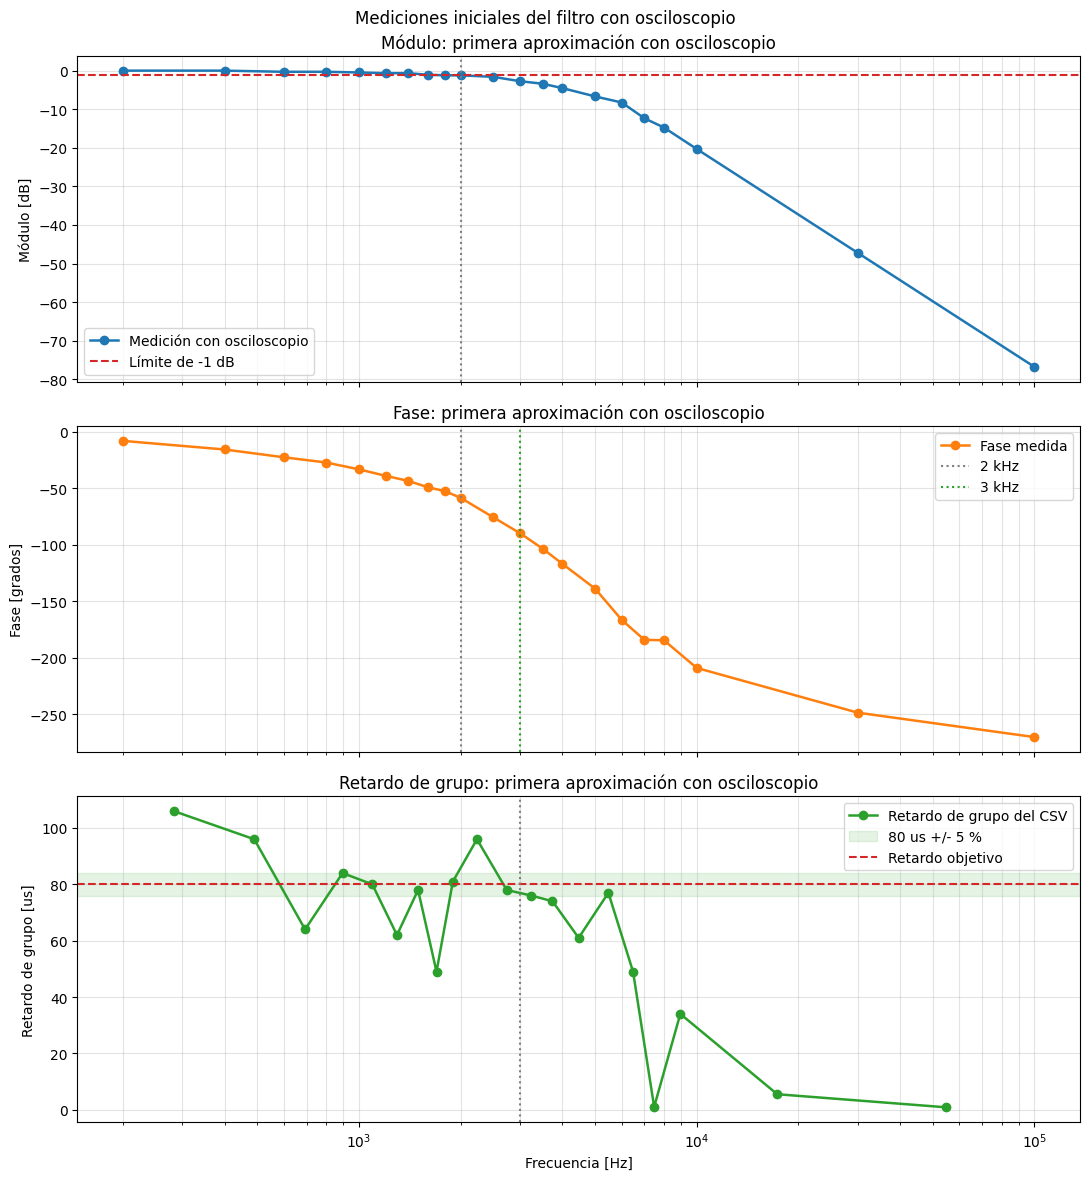

Resumen de la primera aproximación
----------------------------------
CSV utilizado: mediciones_osciloscopio_inicial.csv
Muestras válidas: 21
Atenuación a 2 kHz: 1.214 dB
Retardo de fase a 3 kHz: 83.000 us
Retardo de grupo a 3 kHz: 76.958 us; desvío: 3.802 %
Cumple atenuación a 2 kHz: False
Cumple retardo de grupo a 3 kHz: True


In [34]:
# Primera aproximación experimental: barrido manual con osciloscopio
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np


oscilloscope_candidates = (
    Path("datos/mediciones_osciloscopio_inicial.csv"),
    Path("Lab1/datos/mediciones_osciloscopio_inicial.csv"),
)
oscilloscope_path = next(
    (path for path in oscilloscope_candidates if path.is_file()), None
)
if oscilloscope_path is None:
    raise FileNotFoundError("No se encontró mediciones_osciloscopio_inicial.csv")


def parse_oscilloscope_number(value):
    if value is None or not value.strip():
        return np.nan
    return float(value.replace(",", "."))


oscilloscope_measurements = []
with oscilloscope_path.open(encoding="utf-8-sig", newline="") as file:
    for row in csv.DictReader(file):
        try:
            frequency_value = parse_oscilloscope_number(row["Frecuencia [Hz]"])
            if not np.isfinite(frequency_value):
                continue
            oscilloscope_measurements.append(
                {key: parse_oscilloscope_number(value) for key, value in row.items()}
            )
        except ValueError:
            continue

oscilloscope_frequency = np.array(
    [row["Frecuencia [Hz]"] for row in oscilloscope_measurements]
)
oscilloscope_module_db = np.array(
    [row["Módulo [dB]"] for row in oscilloscope_measurements]
)
oscilloscope_phase_deg = np.array(
    [row["Fase [°]"] for row in oscilloscope_measurements]
)
oscilloscope_phase_delay_us = np.array(
    [row["Delay [µs]"] for row in oscilloscope_measurements]
)
oscilloscope_group_frequency = np.array(
    [row["fm [Hz]"] for row in oscilloscope_measurements]
)
oscilloscope_group_delay_us = np.array(
    [row["Retardo de grupo [µs]"] for row in oscilloscope_measurements]
)

valid_group_delay = (
    np.isfinite(oscilloscope_group_frequency)
    & np.isfinite(oscilloscope_group_delay_us)
    & (oscilloscope_group_delay_us > 0)
)
attenuation_2khz_oscilloscope = -np.interp(
    2e3, oscilloscope_frequency, oscilloscope_module_db
)
group_delay_3khz_oscilloscope = np.interp(
    3e3,
    oscilloscope_group_frequency[valid_group_delay],
    oscilloscope_group_delay_us[valid_group_delay],
)
group_delay_deviation_3khz_oscilloscope = (
    abs(group_delay_3khz_oscilloscope - 80) / 80 * 100
)
index_3khz_oscilloscope = np.argmin(abs(oscilloscope_frequency - 3e3))

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

axes[0].semilogx(
    oscilloscope_frequency,
    oscilloscope_module_db,
    "o-",
    lw=1.8,
    label="Medición con osciloscopio",
)
axes[0].axhline(-1, color="C3", ls="--", label="Límite de -1 dB")
axes[0].axvline(2e3, color="gray", ls=":")
axes[0].set_ylabel("Módulo [dB]")
axes[0].set_title("Módulo: primera aproximación con osciloscopio")
axes[0].grid(True, which="both", alpha=0.35)
axes[0].legend(loc="best")

axes[1].semilogx(
    oscilloscope_frequency,
    oscilloscope_phase_deg,
    "o-",
    lw=1.8,
    color="C1",
    label="Fase medida",
)
axes[1].axvline(2e3, color="gray", ls=":", label="2 kHz")
axes[1].axvline(3e3, color="C2", ls=":", label="3 kHz")
axes[1].set_ylabel("Fase [grados]")
axes[1].set_title("Fase: primera aproximación con osciloscopio")
axes[1].grid(True, which="both", alpha=0.35)
axes[1].legend(loc="best")

axes[2].semilogx(
    oscilloscope_group_frequency[valid_group_delay],
    oscilloscope_group_delay_us[valid_group_delay],
    "o-",
    lw=1.8,
    color="C2",
    label="Retardo de grupo del CSV",
)
axes[2].axhspan(76, 84, color="C2", alpha=0.12, label="80 us +/- 5 %")
axes[2].axhline(80, color="C3", ls="--", label="Retardo objetivo")
axes[2].axvline(3e3, color="gray", ls=":")
axes[2].set_xlabel("Frecuencia [Hz]")
axes[2].set_ylabel("Retardo de grupo [us]")
axes[2].set_title("Retardo de grupo: primera aproximación con osciloscopio")
axes[2].grid(True, which="both", alpha=0.35)
axes[2].legend(loc="best")

fig.suptitle("Mediciones iniciales del filtro con osciloscopio")
fig.tight_layout()
plt.show()

print("Resumen de la primera aproximación")
print("----------------------------------")
print(f"CSV utilizado: {oscilloscope_path.name}")
print(f"Muestras válidas: {len(oscilloscope_measurements)}")
print(f"Atenuación a 2 kHz: {attenuation_2khz_oscilloscope:.3f} dB")
print(
    f"Retardo de fase a 3 kHz: "
    f"{oscilloscope_phase_delay_us[index_3khz_oscilloscope]:.3f} us"
)
print(
    f"Retardo de grupo a 3 kHz: {group_delay_3khz_oscilloscope:.3f} us; "
    f"desvío: {group_delay_deviation_3khz_oscilloscope:.3f} %"
)
print(f"Cumple atenuación a 2 kHz: {attenuation_2khz_oscilloscope <= 1}")
print(
    "Cumple retardo de grupo a 3 kHz: "
    f"{group_delay_deviation_3khz_oscilloscope <= 5}"
)

### 8.7 Barrido instrumental con analizador de audio

El barrido final se obtuvo con un analizador de audio, que excita el filtro con distintas frecuencias y registra automáticamente la respuesta. A diferencia del barrido manual con osciloscopio, este método toma muchos puntos de medición de forma sistemática y permite reconstruir con mayor resolución el módulo y la fase del filtro.

Solo se conservaron los archivos que contienen la respuesta útil del circuito:

- `datos/barrido_instrumental_modulo.csv`: frecuencia y nivel AC medido en dBr.
- `datos/barrido_instrumental_fase.csv`: frecuencia y fase medida en grados.

Se descartaron los pares `Frequency vs Frequency`, porque no representan la transferencia del filtro, y la exportación repetida del módulo.

#### Procesamiento de las mediciones

El código aplica los siguientes pasos:

1. **Carga de los archivos:** se leen las columnas de frecuencia y nivel o fase mediante `csv.DictReader`, y se convierten los valores a números reales.
2. **Obtención del módulo relativo:** el instrumento entrega el nivel en dBr, no directamente $20\log_{10}|V_o/V_i|$. Por eso se calcula como referencia el promedio de las mediciones hasta $100\,\text{Hz}$, donde el filtro se encuentra aproximadamente en la banda pasante. En este caso, la referencia es $54{,}406\,\text{dBr}$, y se resta de todos los niveles:

   $$M(f)=\text{Nivel}(f)-\text{Nivel}_{\mathrm{ref}}$$

   Así, el nivel de la banda pasante queda cercano a $0\,\text{dB}$ y el resultado representa la atenuación relativa del filtro.
3. **Desenvolvimiento de la fase:** la fase puede saltar de $+180°$ a $-180°$ aunque la respuesta física sea continua. `numpy.unwrap` elimina esos saltos de $360°$ para obtener una curva de fase continua.
4. **Interpolación:** se evalúan las curvas en $2\,\text{kHz}$ y $3\,\text{kHz}$ para compararlas con las especificaciones. El módulo relativo interpolado a 2 kHz es $-0{,}974\,\text{dB}$, por lo que cumple el límite de atenuación de $1\,\text{dB}$. La fase desenvuelta interpolada es $-58{,}055°$ a 2 kHz y $-86{,}390°$ a 3 kHz.

#### Modelo utilizado para interpretar la respuesta

La respuesta se modela como un filtro Bessel de tercer orden, separado en una etapa de primer orden y una etapa de segundo orden:

$$H(s)=\frac{\alpha}{s+\alpha}\,\frac{\omega_0^2}{s^2+\frac{\omega_0}{Q}s+\omega_0^2}$$

Los parámetros tienen el siguiente significado:

- $\alpha$: pulsación del polo real de la etapa de primer orden.
- $\omega_0$: pulsación natural de la sección de segundo orden.
- $Q$: factor de calidad de la sección de segundo orden, que determina su amortiguamiento.

El modelo no supone que los parámetros reales del circuito sean exactamente los ideales. Los estima a partir de las mediciones para caracterizar el filtro armado.

#### Método de ajuste

Se realizan dos ajustes independientes mediante mínimos cuadrados no lineales con `scipy.optimize.curve_fit`:

- **Ajuste desde el módulo:** busca los valores de $\alpha$, $\omega_0$ y $Q$ que hacen mínima la diferencia entre el módulo medido y el módulo calculado por el modelo.
- **Ajuste desde la fase:** repite el procedimiento usando la fase medida como objetivo.

En ambos casos, `curve_fit` modifica los tres parámetros dentro de límites físicos previamente definidos y minimiza la suma de los cuadrados de los residuos. El residuo es la diferencia entre el valor medido y el valor predicho por el modelo. El RMSE resume el tamaño medio de esos residuos: cuanto menor es, mejor reproduce el modelo las mediciones.

El ajuste del módulo obtiene $f_\alpha=4624{,}709\,\text{Hz}$, $f_0=4973{,}676\,\text{Hz}$ y $Q=0{,}69535$, con RMSE de $0{,}1041\,\text{dB}$. El ajuste de fase obtiene $f_\alpha=4426{,}329\,\text{Hz}$, $f_0=5065{,}779\,\text{Hz}$ y $Q=0{,}69737$, con RMSE de $0{,}5063°$. La cercanía entre ambos juegos de parámetros indica que módulo y fase describen de forma coherente la misma dinámica del filtro.

### 8.8 Reconstrucción paramétrica y retardo de grupo

Para este modelo, el retardo de grupo se obtiene como $\tau_g(\omega)=-d\varphi/d\omega$:

$$\tau_g(\omega)=\frac{\frac{1}{\alpha}}{1+\left(\frac{\omega}{\alpha}\right)^2}+\frac{\frac{1}{Q\omega_0}\left[1+\left(\frac{\omega}{\omega_0}\right)^2\right]}{\left[1-\left(\frac{\omega}{\omega_0}\right)^2\right]^2+\left(\frac{\omega}{Q\omega_0}\right)^2}$$

La celda de Python aplica esta expresión a cada frecuencia de interés y también a una malla densa de frecuencias. De esta manera, calcula el retardo de grupo que predice el modelo y genera curvas continuas para comparar visualmente el módulo, la fase y el retardo con las mediciones.

La reconstrucción gráfica muestra el módulo y la fase medidos por el analizador frente a ambos modelos, junto con el retardo derivado. A 3 kHz, el modelo ajustado por módulo predice $78{,}459\,\mu s$ y el modelo ajustado por fase predice $77{,}890\,\mu s$; la diferencia entre ambos es menor que $0{,}6\,\mu s$. Estos valores se comparan con el objetivo de $80\,\mu s$ y permiten verificar el comportamiento temporal del filtro.

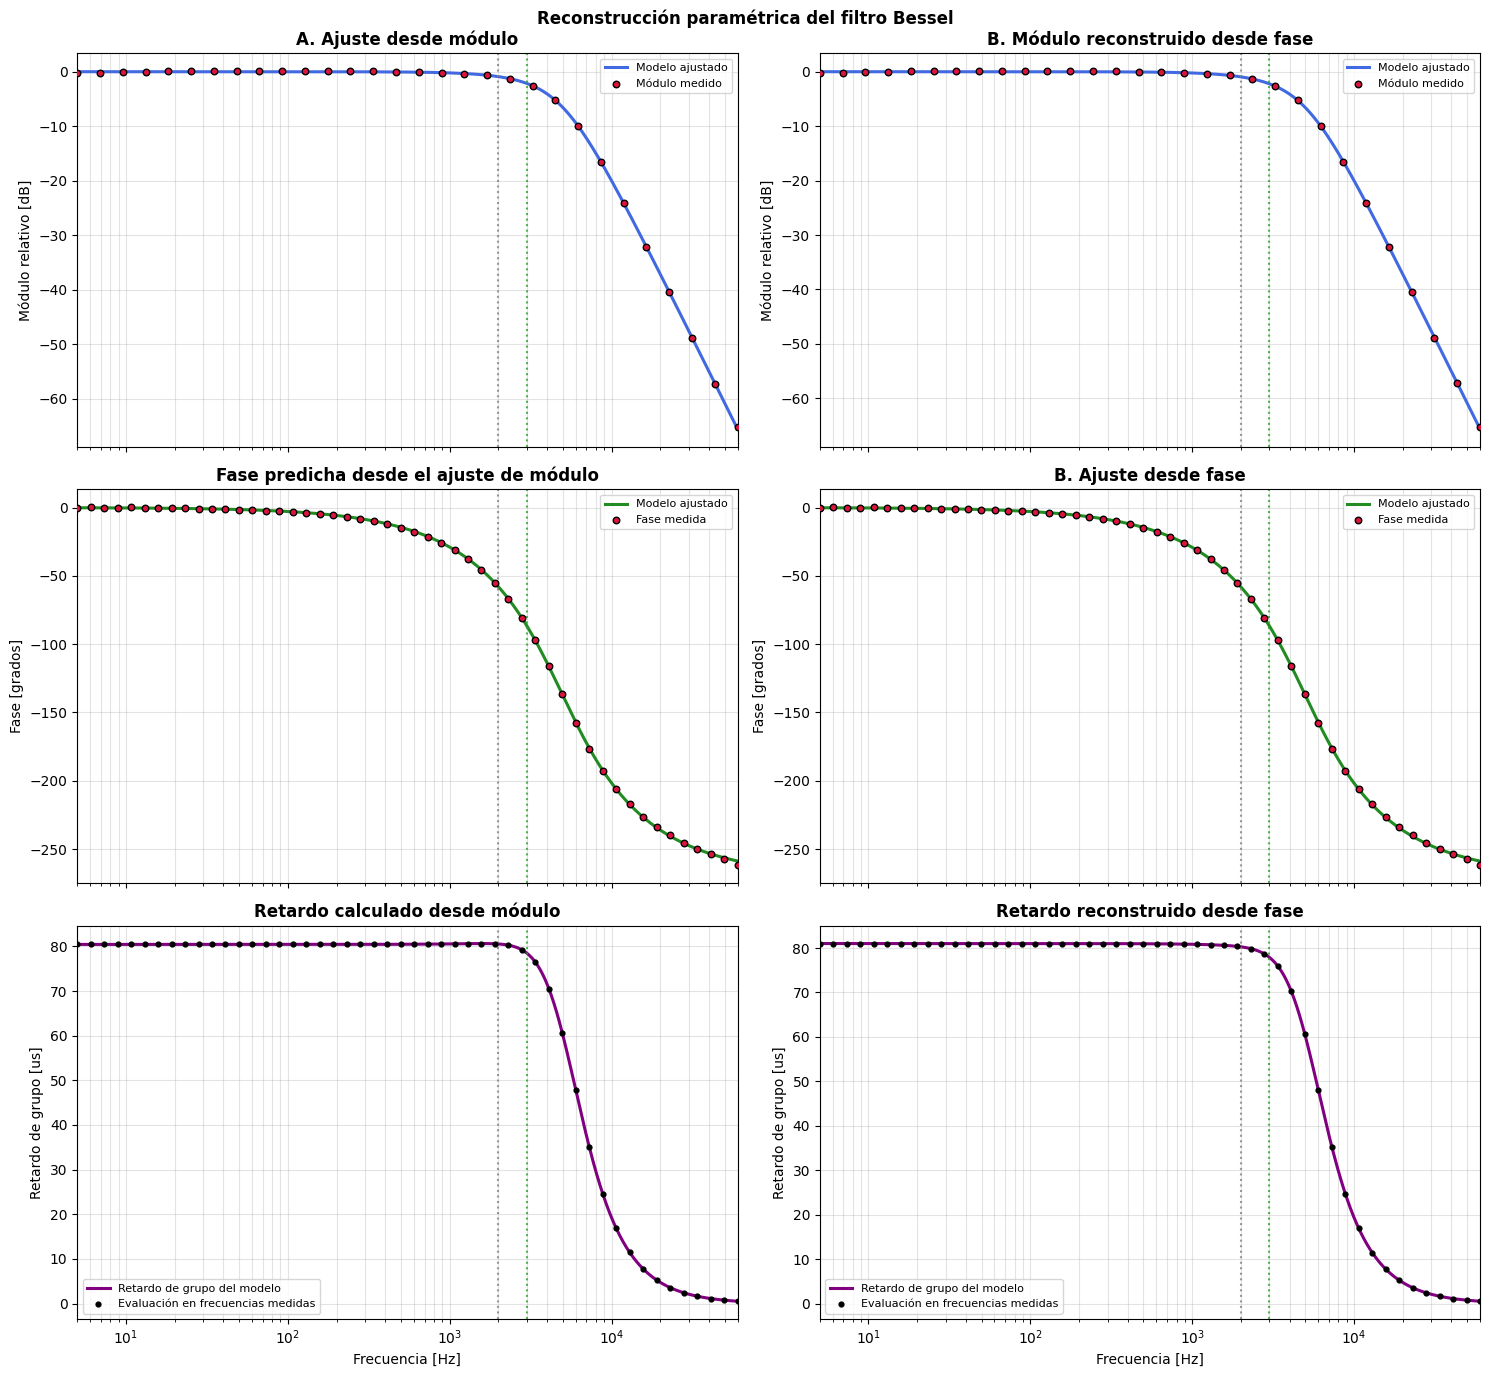

### Modelo ajustado y retardo de grupo

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Resumen del ajuste
-------------------
Ajuste por módulo:
  f_alpha = 4624.709 Hz
  f_0 = 4973.676 Hz
  Q = 0.69535
  RMSE = 0.1041
  tau_g(3 kHz) = 78.459 us
Ajuste por fase:
  f_alpha = 4426.329 Hz
  f_0 = 5065.779 Hz
  Q = 0.69737
  RMSE = 0.5063
  tau_g(3 kHz) = 77.890 us


In [35]:
# Reconstrucción del filtro a partir de los barridos instrumentales
from pathlib import Path
import csv

from IPython.display import Math, Markdown, display
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


data_directories = (Path("datos"), Path("Lab1/datos"))
data_dir = next((path for path in data_directories if path.is_dir()), None)
if data_dir is None:
    raise FileNotFoundError("No se encontró el directorio datos/")

module_path = data_dir / "barrido_instrumental_modulo.csv"
phase_path = data_dir / "barrido_instrumental_fase.csv"


def load_columns(path, x_column, y_column):
    with path.open(encoding="utf-8", newline="") as file:
        rows = list(csv.DictReader(file))
    return (
        np.array([float(row[x_column]) for row in rows]),
        np.array([float(row[y_column]) for row in rows]),
    )


def model_magnitude(omega, alpha, omega_0, quality_factor):
    first_order = 1 + (omega / alpha) ** 2
    second_order = (1 - (omega / omega_0) ** 2) ** 2 + (
        omega / (quality_factor * omega_0)
    ) ** 2
    return -10 * np.log10(first_order) - 10 * np.log10(second_order)


def model_phase(omega, alpha, omega_0, quality_factor):
    return np.degrees(
        -np.arctan(omega / alpha)
        - np.arctan2(
            omega / (quality_factor * omega_0),
            1 - (omega / omega_0) ** 2,
        )
    )


def model_group_delay(omega, alpha, omega_0, quality_factor):
    first_order = (1 / alpha) / (1 + (omega / alpha) ** 2)
    second_order = (
        (1 / (quality_factor * omega_0)) * (1 + (omega / omega_0) ** 2)
    ) / (
        (1 - (omega / omega_0) ** 2) ** 2
        + (omega / (quality_factor * omega_0)) ** 2
    )
    return first_order + second_order


def fit_model(model, frequency, values):
    limits = (
        [2 * np.pi * 500, 2 * np.pi * 500, 0.1],
        [2 * np.pi * 30e3, 2 * np.pi * 30e3, 5.0],
    )
    initial_guess = [2 * np.pi * 4.5e3, 2 * np.pi * 5e3, 0.7]
    return curve_fit(
        model,
        2 * np.pi * frequency,
        values,
        p0=initial_guess,
        bounds=limits,
        maxfev=50_000,
    )[0]


def latex_number(value):
    mantissa, exponent = f"{value:.5e}".split("e")
    return rf"{float(mantissa):.5f}\times10^{{{int(exponent)}}}"


def transfer_function_latex(label, parameters):
    alpha, omega_0, quality_factor = parameters
    numerator = alpha * omega_0**2
    return (
        rf"H_{{\mathrm{{{label}}}}}(s)="
        rf"\frac{{{latex_number(numerator)}}}"
        rf"{{(s+{alpha:.3f})"
        rf"\left(s^2+{omega_0 / quality_factor:.3f}s"
        rf"+{latex_number(omega_0**2)}\right)}}"
    )


module_frequency, module_dbr = load_columns(
    module_path, "Frecuencia [Hz]", "Nivel [dBr]"
)
phase_frequency, phase_deg_wrapped = load_columns(
    phase_path, "Frecuencia [Hz]", "Fase [deg]"
)

reference_mask = module_frequency <= 100
module_reference_dbr = module_dbr[reference_mask].mean()
module_db = module_dbr - module_reference_dbr
phase_deg = np.rad2deg(np.unwrap(np.deg2rad(phase_deg_wrapped)))

parameters_magnitude = fit_model(model_magnitude, module_frequency, module_db)
parameters_phase = fit_model(model_phase, phase_frequency, phase_deg)
alpha_magnitude, omega_0_magnitude, quality_magnitude = parameters_magnitude
alpha_phase, omega_0_phase, quality_phase = parameters_phase

frequency_smooth = np.logspace(np.log10(5), np.log10(60e3), 1000)
omega_smooth = 2 * np.pi * frequency_smooth
omega_module = 2 * np.pi * module_frequency
omega_phase = 2 * np.pi * phase_frequency

residual_magnitude = module_db - model_magnitude(omega_module, *parameters_magnitude)
residual_phase = phase_deg - model_phase(omega_phase, *parameters_phase)
group_delay_magnitude_3khz = model_group_delay(
    2 * np.pi * 3e3, *parameters_magnitude
)
group_delay_phase_3khz = model_group_delay(2 * np.pi * 3e3, *parameters_phase)

fig, axes = plt.subplots(3, 2, figsize=(15, 14), sharex="col")

plot_definitions = (
    (
        0,
        0,
        model_magnitude,
        parameters_magnitude,
        module_frequency,
        module_db,
        "Módulo relativo [dB]",
        "A. Ajuste desde módulo",
        "Módulo medido",
        "royalblue",
    ),
    (
        0,
        1,
        model_magnitude,
        parameters_phase,
        module_frequency,
        module_db,
        "Módulo relativo [dB]",
        "B. Módulo reconstruido desde fase",
        "Módulo medido",
        "royalblue",
    ),
    (
        1,
        0,
        model_phase,
        parameters_magnitude,
        phase_frequency,
        phase_deg,
        "Fase [grados]",
        "Fase predicha desde el ajuste de módulo",
        "Fase medida",
        "forestgreen",
    ),
    (
        1,
        1,
        model_phase,
        parameters_phase,
        phase_frequency,
        phase_deg,
        "Fase [grados]",
        "B. Ajuste desde fase",
        "Fase medida",
        "forestgreen",
    ),
)

for (
    row,
    column,
    model,
    parameters,
    measured_frequency,
    measured_values,
    ylabel,
    title,
    measured_label,
    color,
) in plot_definitions:
    axis = axes[row, column]
    axis.semilogx(
        frequency_smooth,
        model(omega_smooth, *parameters),
        color=color,
        lw=2.2,
        label="Modelo ajustado",
    )
    axis.scatter(
        measured_frequency,
        measured_values,
        color="crimson",
        edgecolors="black",
        s=22,
        label=measured_label,
        zorder=3,
    )
    axis.set_ylabel(ylabel)
    axis.set_title(title, fontweight="bold")

for column, (parameters, title) in enumerate(
    (
        (parameters_magnitude, "Retardo calculado desde módulo"),
        (parameters_phase, "Retardo reconstruido desde fase"),
    )
):
    axis = axes[2, column]
    axis.semilogx(
        frequency_smooth,
        model_group_delay(omega_smooth, *parameters) * 1e6,
        color="purple",
        lw=2.2,
        label="Retardo de grupo del modelo",
    )
    axis.scatter(
        phase_frequency,
        model_group_delay(omega_phase, *parameters) * 1e6,
        color="black",
        s=12,
        label="Evaluación en frecuencias medidas",
        zorder=3,
    )
    axis.set_xlabel("Frecuencia [Hz]")
    axis.set_ylabel("Retardo de grupo [us]")
    axis.set_title(title, fontweight="bold")

for row in axes:
    for axis in row:
        axis.set_xlim(5, 60e3)
        axis.axvline(2e3, color="gray", ls=":", alpha=0.8)
        axis.axvline(3e3, color="C2", ls=":", alpha=0.8)
        axis.grid(True, which="both", alpha=0.35)
        axis.legend(loc="best", fontsize=8)

fig.suptitle("Reconstrucción paramétrica del filtro Bessel", fontweight="bold")
fig.tight_layout()
plt.show()

display(Markdown("### Modelo ajustado y retardo de grupo"))
display(
    Math(
        r"H(s)=\frac{\alpha}{s+\alpha}"
        r"\frac{\omega_0^2}{s^2+\frac{\omega_0}{Q}s+\omega_0^2}"
    )
)
display(
    Math(
        r"\tau_g(\omega)="
        r"\frac{\frac{1}{\alpha}}{1+\left(\frac{\omega}{\alpha}\right)^2}"
        r"+\frac{\frac{1}{Q\omega_0}"
        r"\left[1+\left(\frac{\omega}{\omega_0}\right)^2\right]}"
        r"{\left[1-\left(\frac{\omega}{\omega_0}\right)^2\right]^2"
        r"+\left(\frac{\omega}{Q\omega_0}\right)^2}"
    )
)
display(Math(transfer_function_latex("mag", parameters_magnitude)))
display(Math(transfer_function_latex("fase", parameters_phase)))

print("Resumen del ajuste")
print("-------------------")
for label, parameters, residual, group_delay_3khz in (
    (
        "Ajuste por módulo",
        parameters_magnitude,
        residual_magnitude,
        group_delay_magnitude_3khz,
    ),
    ("Ajuste por fase", parameters_phase, residual_phase, group_delay_phase_3khz),
):
    alpha, omega_0, quality_factor = parameters
    print(f"{label}:")
    print(f"  f_alpha = {alpha / (2 * np.pi):.3f} Hz")
    print(f"  f_0 = {omega_0 / (2 * np.pi):.3f} Hz")
    print(f"  Q = {quality_factor:.5f}")
    print(f"  RMSE = {np.sqrt(np.mean(residual**2)):.4f}")
    print(f"  tau_g(3 kHz) = {group_delay_3khz * 1e6:.3f} us")

In [36]:
# Verificación adicional de ganancia en continua y atenuación a 2 kHz
for label, parameters in (
    ("Ajuste por módulo", parameters_magnitude),
    ("Ajuste por fase", parameters_phase),
):
    module_2khz_db = model_magnitude(2 * np.pi * 2e3, *parameters)
    attenuation_2khz_db = -module_2khz_db
    gain_dc_db = model_magnitude(0, *parameters)
    gain_dc = 10 ** (gain_dc_db / 20)
    print(f"{label}:")
    print(f"  Atenuación a 2 kHz: {attenuation_2khz_db:.3f} dB")
    print(f"  Ganancia en continua: {gain_dc:.6f} V/V ({gain_dc_db:.3f} dB)")

Ajuste por módulo:
  Atenuación a 2 kHz: 0.903 dB
  Ganancia en continua: 1.000000 V/V (-0.000 dB)
Ajuste por fase:
  Atenuación a 2 kHz: 0.948 dB
  Ganancia en continua: 1.000000 V/V (-0.000 dB)


<a id="p9"></a>

***

## 9. Conclusiones

1. La síntesis del filtro Bessel de tercer orden mediante una etapa Sallen-Key y una etapa RC permitió reproducir la respuesta temporal esperada. El diseño propio con valores comerciales, incluido $C_1=2{,}35304\,\text{nF}$ realizado con $3{,}3\,\text{nF}$ y $8{,}2\,\text{nF}$ en serie, obtuvo en simulación una atenuación de $0{,}899\,\text{dB}$ a 2 kHz y un retardo de grupo de $78{,}048\,\mu s$ a 3 kHz; ambos valores satisfacen las especificaciones de diseño.

2. La primera aproximación experimental, obtenida mediante el osciloscopio y conservada en `mediciones_osciloscopio_inicial.csv`, mostró $1{,}214\,\text{dB}$ de atenuación a 2 kHz, por encima del máximo de $1\,\text{dB}$. Sin embargo, su retardo de grupo interpolado a 3 kHz fue $76{,}958\,\mu s$, con un desvío de $3{,}802\,\%$, dentro de la tolerancia de $\pm5\,\%$. El retardo de fase directo leído en ese punto fue $83\,\mu s$ y no debe confundirse con el retardo de grupo.

3. El barrido de mayor resolución con el analizador de audio caracterizó el comportamiento del filtro de forma más consistente: el módulo relativo a 2 kHz fue $-0{,}974\,\text{dB}$, dentro de la especificación. Los ajustes independientes de módulo y fase entregaron parámetros cercanos, con $Q\approx0{,}695$, y predijeron $\tau_g(3\,\text{kHz})=78{,}459\,\mu s$ y $77{,}890\,\mu s$, respectivamente.

4. Las diferencias entre la simulación, las mediciones manuales y el barrido instrumental son compatibles con tolerancias de componentes, ajuste de presets, condiciones de fuente y carga, no idealidades del TL082 y resolución del método de medición. Por ello, la primera aproximación se conserva como evidencia del procedimiento, mientras que el barrido instrumental y su reconstrucción paramétrica constituyen la referencia final para caracterizar el montaje.

En conjunto, el circuito presenta una respuesta compatible con un pasabajos Bessel de orden 3: banda de paso prácticamente plana, transición suave, fase continua y retardo de grupo próximo a $80\,\mu s$ alrededor de 3 kHz.